In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

alphaゲート

In [41]:
# CSVファイルを読み込む（nrowsで読み込む行数を指定できるのでメモリに優しい）
df = pd.read_csv('run2025_none.csv')

LASX = df['LASX']
LAStiming = df['LASQ1timing']
TOT = df['LASTOT']

In [42]:
#alpha_gateかける
alpha_gated=df[
    (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
]

Text(0, 0.5, 'counts')

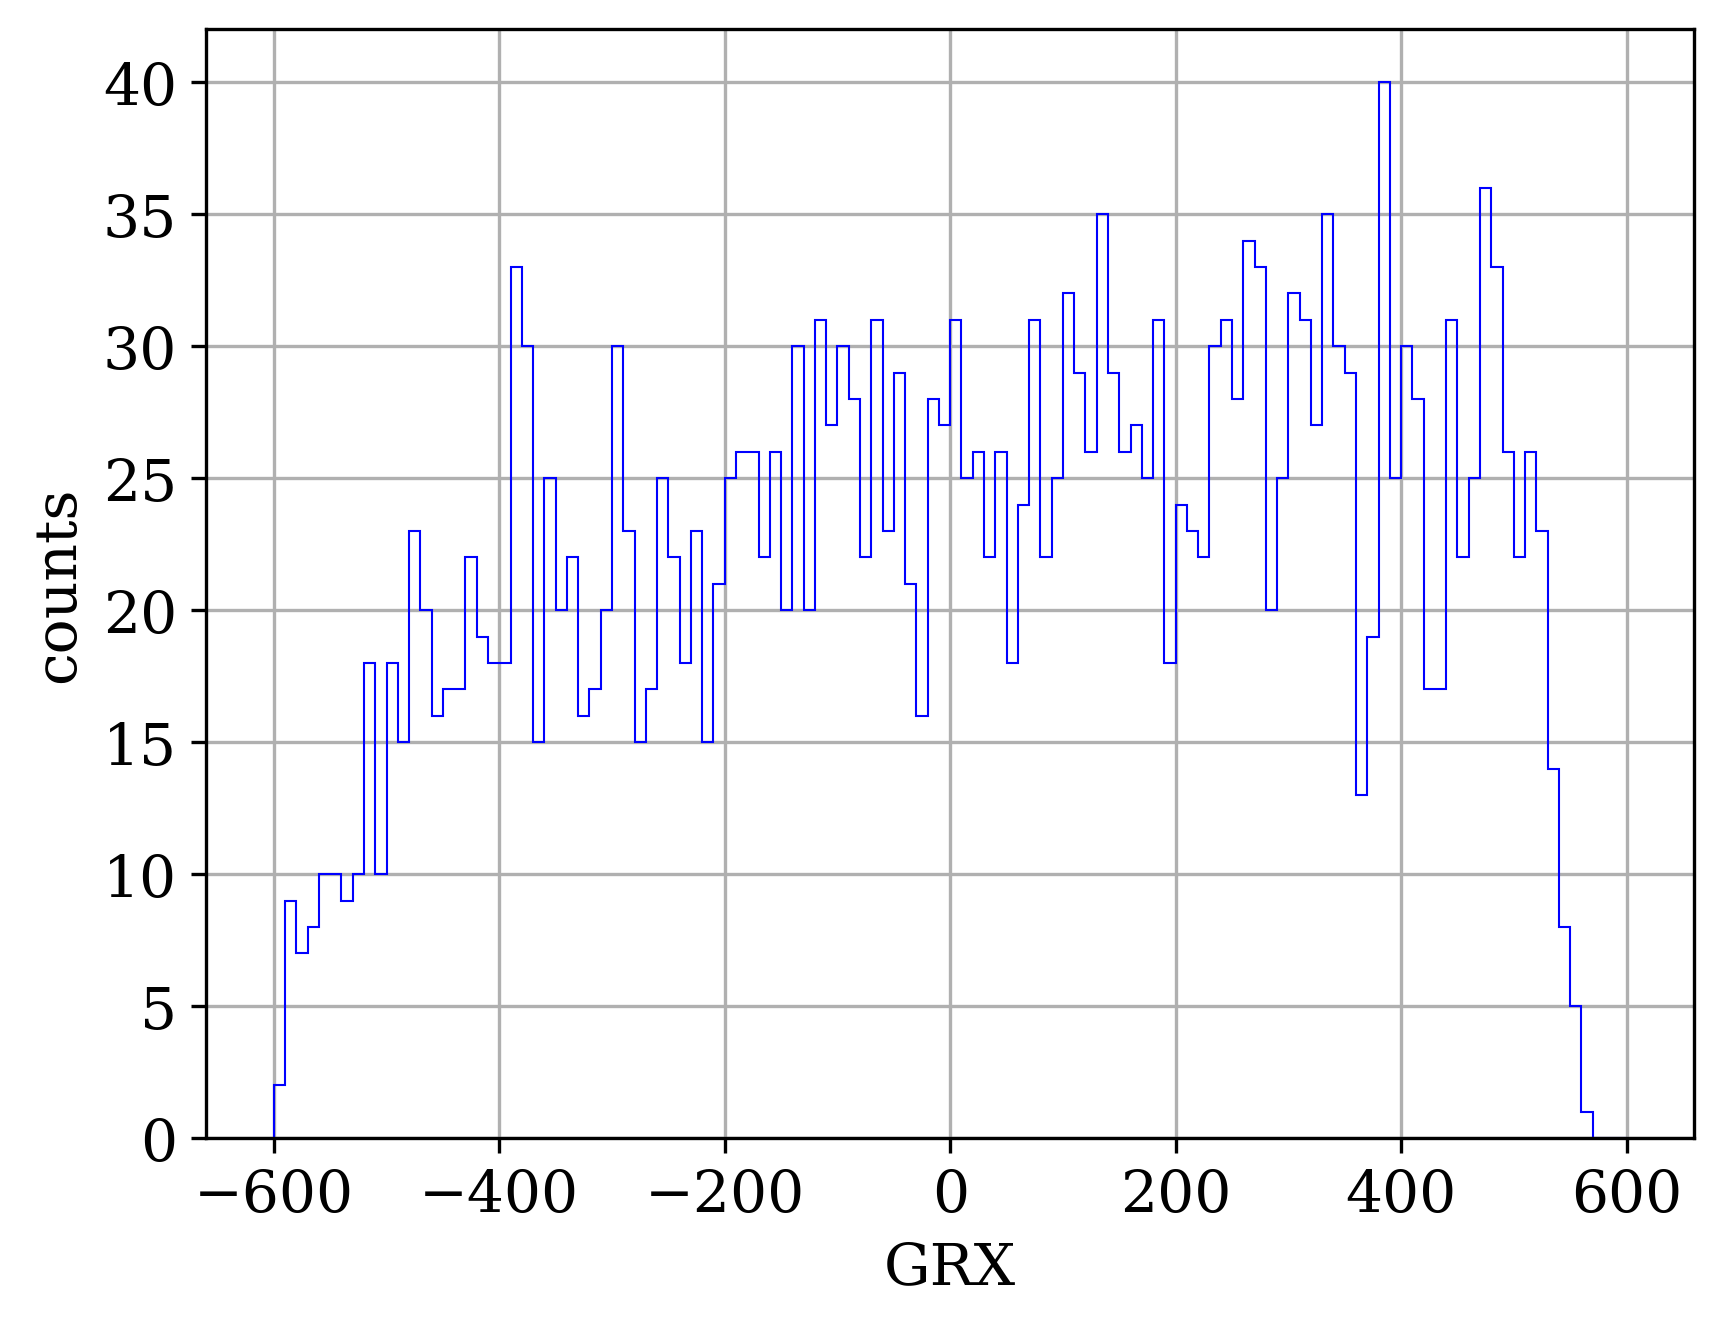

In [43]:
GRX=alpha_gated['GRX']

variables=GRX
#hist range
range_min=-600
range_max=600
#bin width
x_bin_width=10

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('GRX')
ax.set_ylabel('counts')

protonゲート

In [44]:
xdp=df['GRX']
adp=df['GRA']
ydp=df['GRY']
bdp=df['GRB']
GRQ2=df['GRQ2charge']

In [45]:
#トラッキングできたやつを抽出
tracking_gated=df[
    (xdp!=-9999) & (ydp!=-9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']

In [46]:
#protonゲート
proton_gated=tracking_gated[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
]

xdp_proton=proton_gated['GRX']
adp_proton=proton_gated['GRA']
ydp_proton=proton_gated['GRY']
bdp_proton=proton_gated['GRB']
GRQ2_proton=proton_gated['GRQ2charge']

In [47]:
#合わせる

gated = df[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
]

GRX_gated = gated['GRX']
LASX_gated = gated['LASX']
print(GRX_gated)

79         76.6026
85        254.6680
242       441.3170
402       -34.5970
590        58.1263
            ...   
546736    -15.0700
546858   -474.1850
547010    456.0580
547230    -72.4815
547924    183.8910
Name: GRX, Length: 2186, dtype: float64


In [48]:
p = []
for n in GRX_gated:
    p.append((n * -0.0000454324 + 0.0017199490 + 1) * 832)

# p = []
# for n in GRX_gated:
#     p.append((n * -0.0000454324 + 0.0027089081 + 1) * 832)

print(p)

[830.5354379177523, 823.8046091032576, 816.7493222962944, 834.7387557540096, 831.2338375643161, 817.6013666143232, 848.5630718096896, 822.5532859541504, 852.5420632092416, 832.350291181161, 849.9766693147392, 823.1389175862528, 827.0784460397056, 823.9844981458688, 845.013221049088, 828.4839165970432, 828.4836141989888, 819.732743701248, 827.0706592898048, 837.2832085832448, 830.8372425159705, 819.6345021333249, 846.9925297144064, 828.7562638447872, 838.4831240631039, 838.3508249143041, 825.507034550016, 829.6973530499097, 819.7754196266751, 818.7805300276992, 827.4398873142272, 851.5051024809471, 820.2097388323073, 823.8029459139584, 827.6465763844096, 850.8849596708864, 813.6018877465856, 846.4185026076416, 828.6089203927808, 824.3423484434944, 829.4978950732032, 817.6934846216448, 839.6492843601409, 822.419361415808, 834.1627592799156, 824.0687160040192, 815.5450220446464, 845.9382944972543, 849.2712124535807, 820.328089870848, 834.4822239245107, 826.6420856472064, 840.165780237056,

In [49]:
print(p)

[830.5354379177523, 823.8046091032576, 816.7493222962944, 834.7387557540096, 831.2338375643161, 817.6013666143232, 848.5630718096896, 822.5532859541504, 852.5420632092416, 832.350291181161, 849.9766693147392, 823.1389175862528, 827.0784460397056, 823.9844981458688, 845.013221049088, 828.4839165970432, 828.4836141989888, 819.732743701248, 827.0706592898048, 837.2832085832448, 830.8372425159705, 819.6345021333249, 846.9925297144064, 828.7562638447872, 838.4831240631039, 838.3508249143041, 825.507034550016, 829.6973530499097, 819.7754196266751, 818.7805300276992, 827.4398873142272, 851.5051024809471, 820.2097388323073, 823.8029459139584, 827.6465763844096, 850.8849596708864, 813.6018877465856, 846.4185026076416, 828.6089203927808, 824.3423484434944, 829.4978950732032, 817.6934846216448, 839.6492843601409, 822.419361415808, 834.1627592799156, 824.0687160040192, 815.5450220446464, 845.9382944972543, 849.2712124535807, 820.328089870848, 834.4822239245107, 826.6420856472064, 840.165780237056,


p = []
for n in GRX_gated:
    p.append((n * -0.0000454324 + 0.0017199490 + 1) * 832)

Tp = []
for n in p:
    Tp.append((n ** 2 + 938.27 ** 2) ** 0.5 - 938.27)


Text(0, 0.5, 'counts')

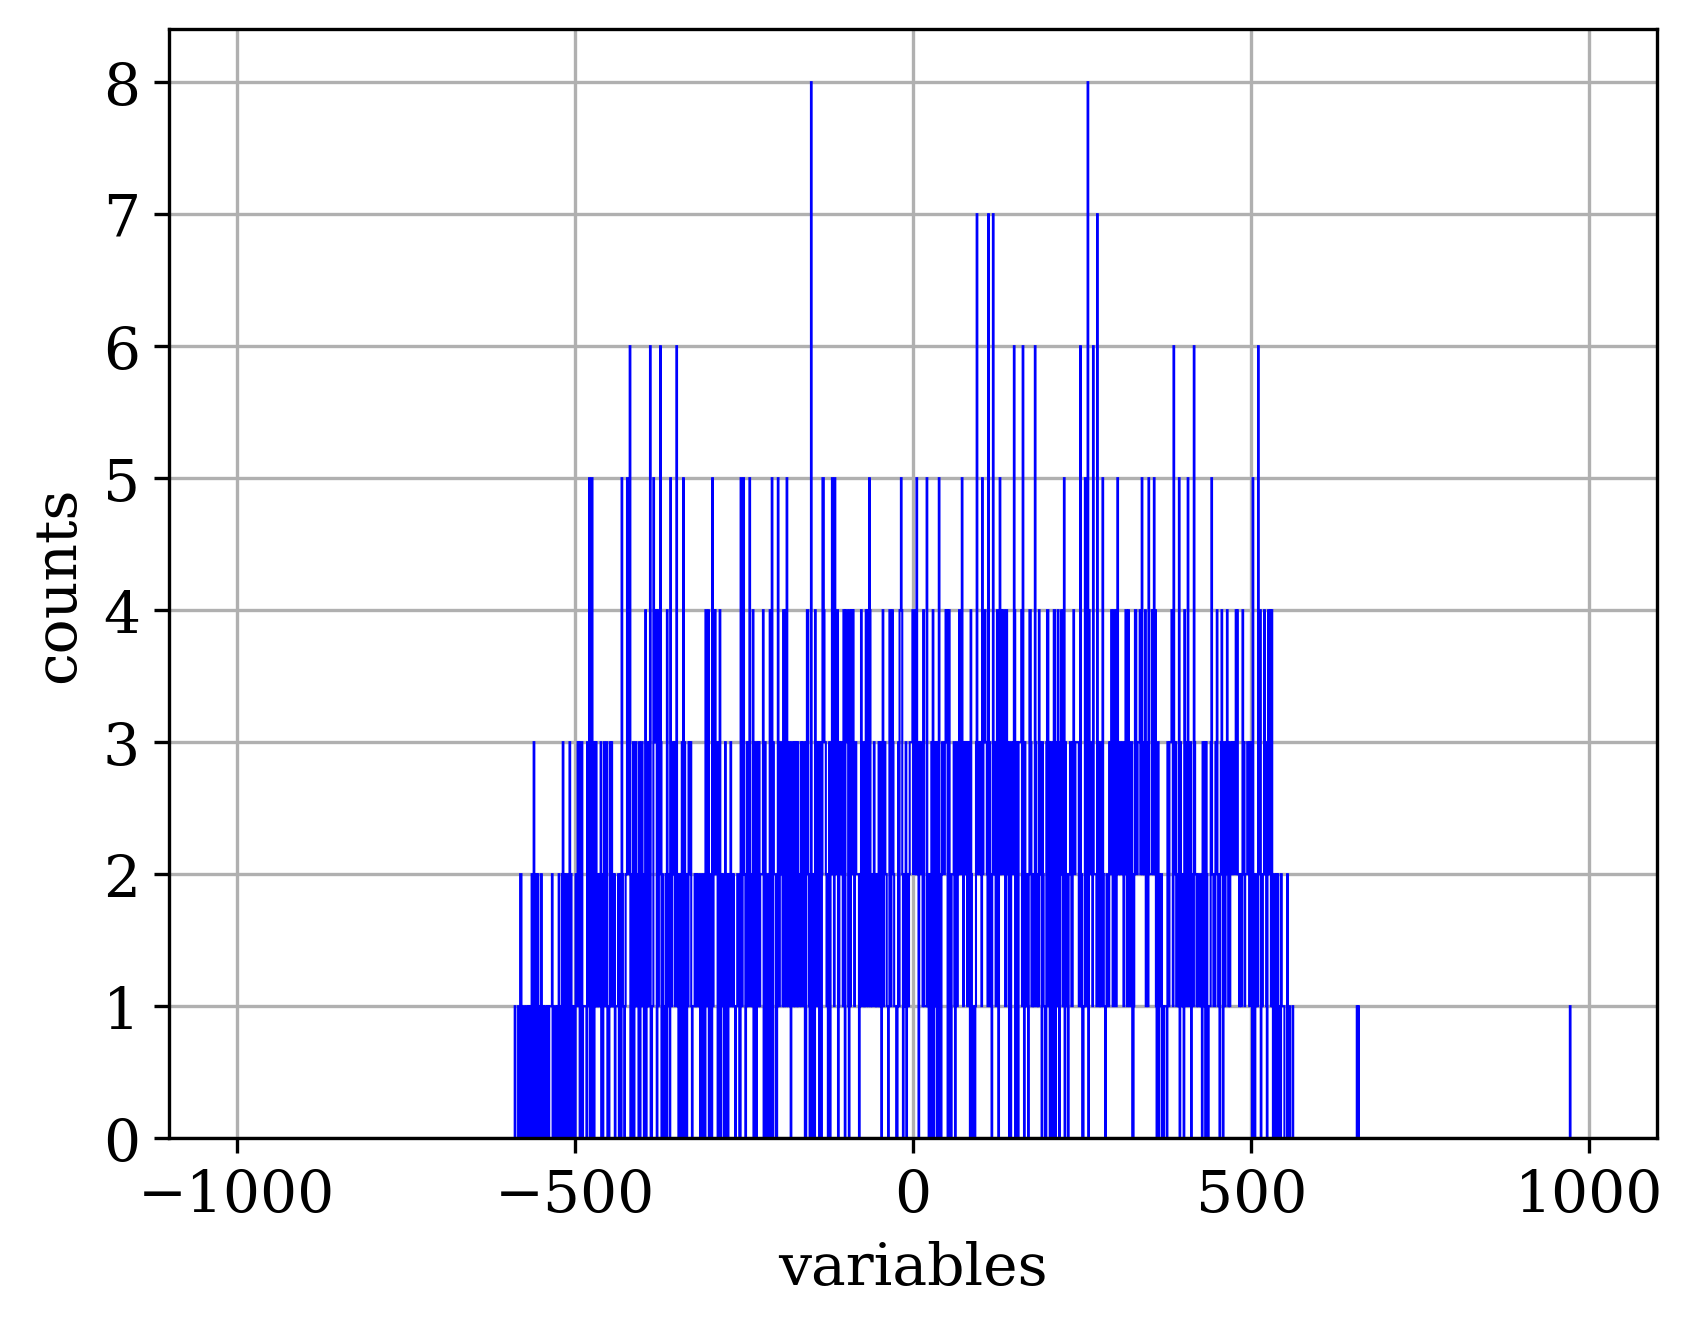

In [50]:
variables = GRX_gated

#hist range
range_min = -1000
range_max = 1000
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variables')
ax.set_ylabel('counts')

In [51]:
Tp = []
for n in p:
    Tp.append((n ** 2 + 938.27 ** 2) ** 0.5 - 938.27)

print(len(Tp))
print(Tp)


2186
[314.7821563515354, 310.3310679475535, 305.68741421137725, 317.5721012443212, 315.24517167200656, 306.24700976306826, 326.80307288515814, 309.50582166588333, 329.47546437408755, 315.9857953341748, 327.7516946321962, 309.8919568569888, 312.49350634460643, 310.4497628309962, 324.42471237023665, 313.42333023707397, 313.42313008269684, 307.64828142778924, 312.4883573009106, 319.2647964471812, 314.98221581752705, 307.58364709798207, 325.75014948022476, 313.60361093761003, 320.06403444340754, 319.97588158852886, 311.4549525361815, 314.226822574024, 307.67635981012086, 307.0219935711623, 312.73254197127085, 328.7783544249951, 307.9621647972988, 310.3299706056846, 312.86926015485346, 328.36167791356206, 303.62316152590506, 325.3655781856421, 313.5060725682888, 310.685924097138, 314.09470360309774, 306.3075298038639, 320.841398418145, 309.4175405852161, 317.189319081858, 310.50533671854396, 304.8970345861826, 325.04397166220065, 327.27817577300266, 308.04006091227325, 317.4016031455028, 31

In [52]:
#T_alphaを求める。
#Sαを誤って0.515引いてしまっているが後で修正するのでおk
T_alpha = []
for n in Tp:
    T_alpha.append((392 - n - 0.515))
print(T_alpha)

# T_alpha = []
# for n in Tp:
#     T_alpha.append((392 - n + 7.37))
# print(T_alpha)

[76.70284364846462, 81.1539320524465, 85.79758578862275, 73.91289875567882, 76.23982832799344, 85.23799023693174, 64.68192711484186, 81.97917833411667, 62.00953562591245, 75.49920466582522, 63.73330536780382, 81.59304314301117, 78.99149365539357, 81.03523716900382, 67.06028762976335, 78.06166976292603, 78.06186991730316, 83.83671857221076, 78.9966426990894, 72.2202035528188, 76.50278418247295, 83.90135290201793, 65.73485051977524, 77.88138906238997, 71.42096555659246, 71.50911841147114, 80.03004746381849, 77.25817742597597, 83.80864018987914, 84.46300642883772, 78.75245802872915, 62.70664557500491, 83.52283520270122, 81.1550293943154, 78.61573984514654, 63.12332208643794, 87.86183847409494, 66.11942181435789, 77.9789274317112, 80.79907590286199, 77.39029639690226, 85.17747019613613, 70.64360158185501, 82.0674594147839, 74.295680918142, 80.97966328145604, 86.5879654138174, 66.44102833779935, 64.20682422699734, 83.44493908772675, 74.0833968544972, 79.27999798550023, 70.29911304669291, 73

In [53]:
T_alpha_test = []
for n in GRX_gated:
    # T_alpha_test.append((392 - (((n * -0.0000454324 + 0.0017199490 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 0.515)
    T_alpha_test.append((392 - ((((n * -0.0000454324 + 0.0017199490 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 0.515))
print(T_alpha_test)

[76.70284364846462, 81.1539320524465, 85.79758578862275, 73.91289875567882, 76.23982832799344, 85.23799023693174, 64.68192711484186, 81.97917833411667, 62.00953562591245, 75.49920466582522, 63.73330536780382, 81.59304314301117, 78.99149365539357, 81.03523716900382, 67.06028762976335, 78.06166976292603, 78.06186991730316, 83.83671857221076, 78.9966426990894, 72.2202035528188, 76.50278418247295, 83.90135290201793, 65.73485051977524, 77.88138906238997, 71.42096555659246, 71.50911841147114, 80.03004746381849, 77.25817742597597, 83.80864018987914, 84.46300642883772, 78.75245802872915, 62.70664557500491, 83.52283520270122, 81.1550293943154, 78.61573984514654, 63.12332208643794, 87.86183847409494, 66.11942181435789, 77.9789274317112, 80.79907590286199, 77.39029639690226, 85.17747019613613, 70.64360158185501, 82.0674594147839, 74.295680918142, 80.97966328145604, 86.5879654138174, 66.44102833779935, 64.20682422699734, 83.44493908772675, 74.0833968544972, 79.27999798550023, 70.29911304669291, 73

Text(0, 0.5, 'counts')

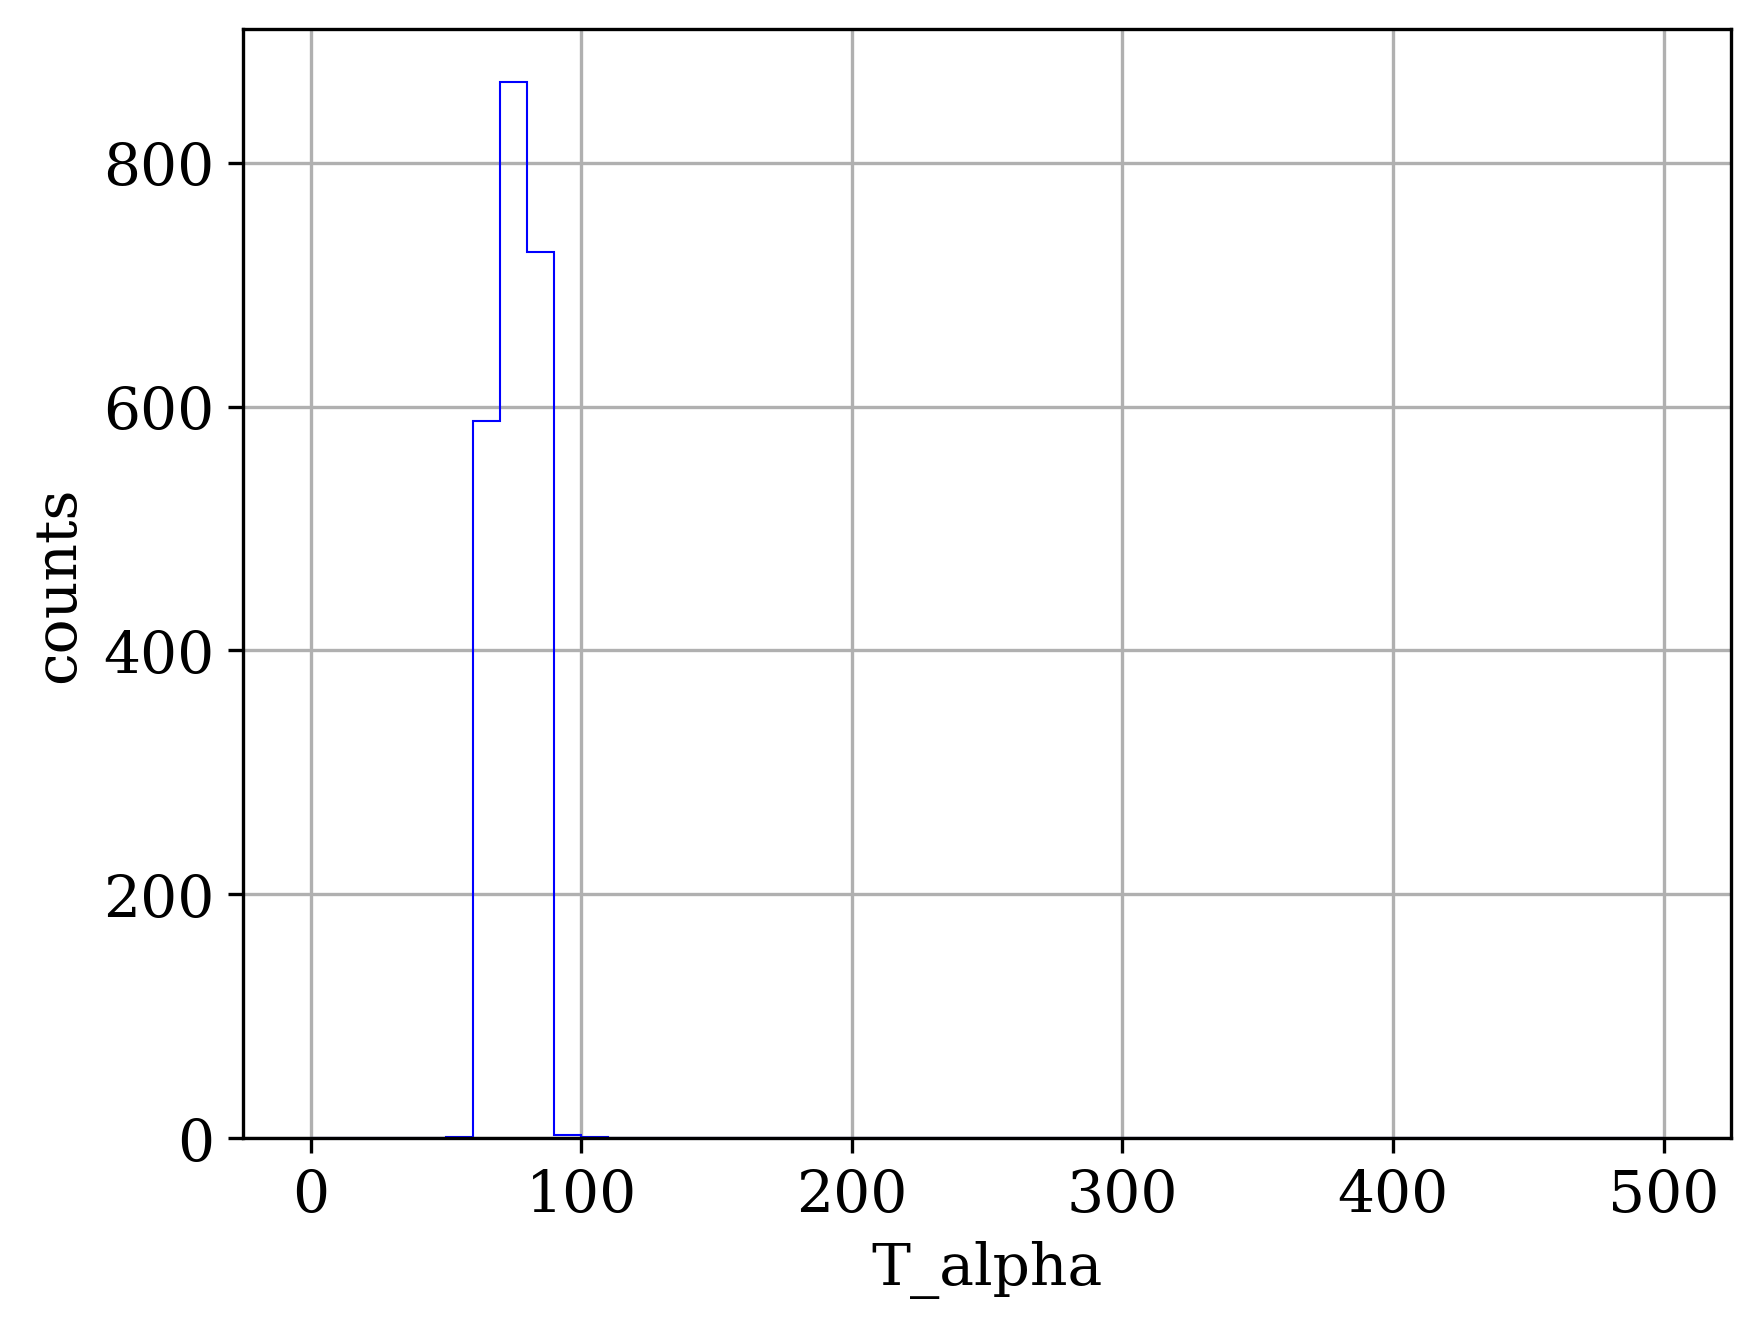

In [54]:
variables = T_alpha

#hist range
range_min=0
range_max=500
#bin width
x_bin_width=10

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('T_alpha')
ax.set_ylabel('counts')

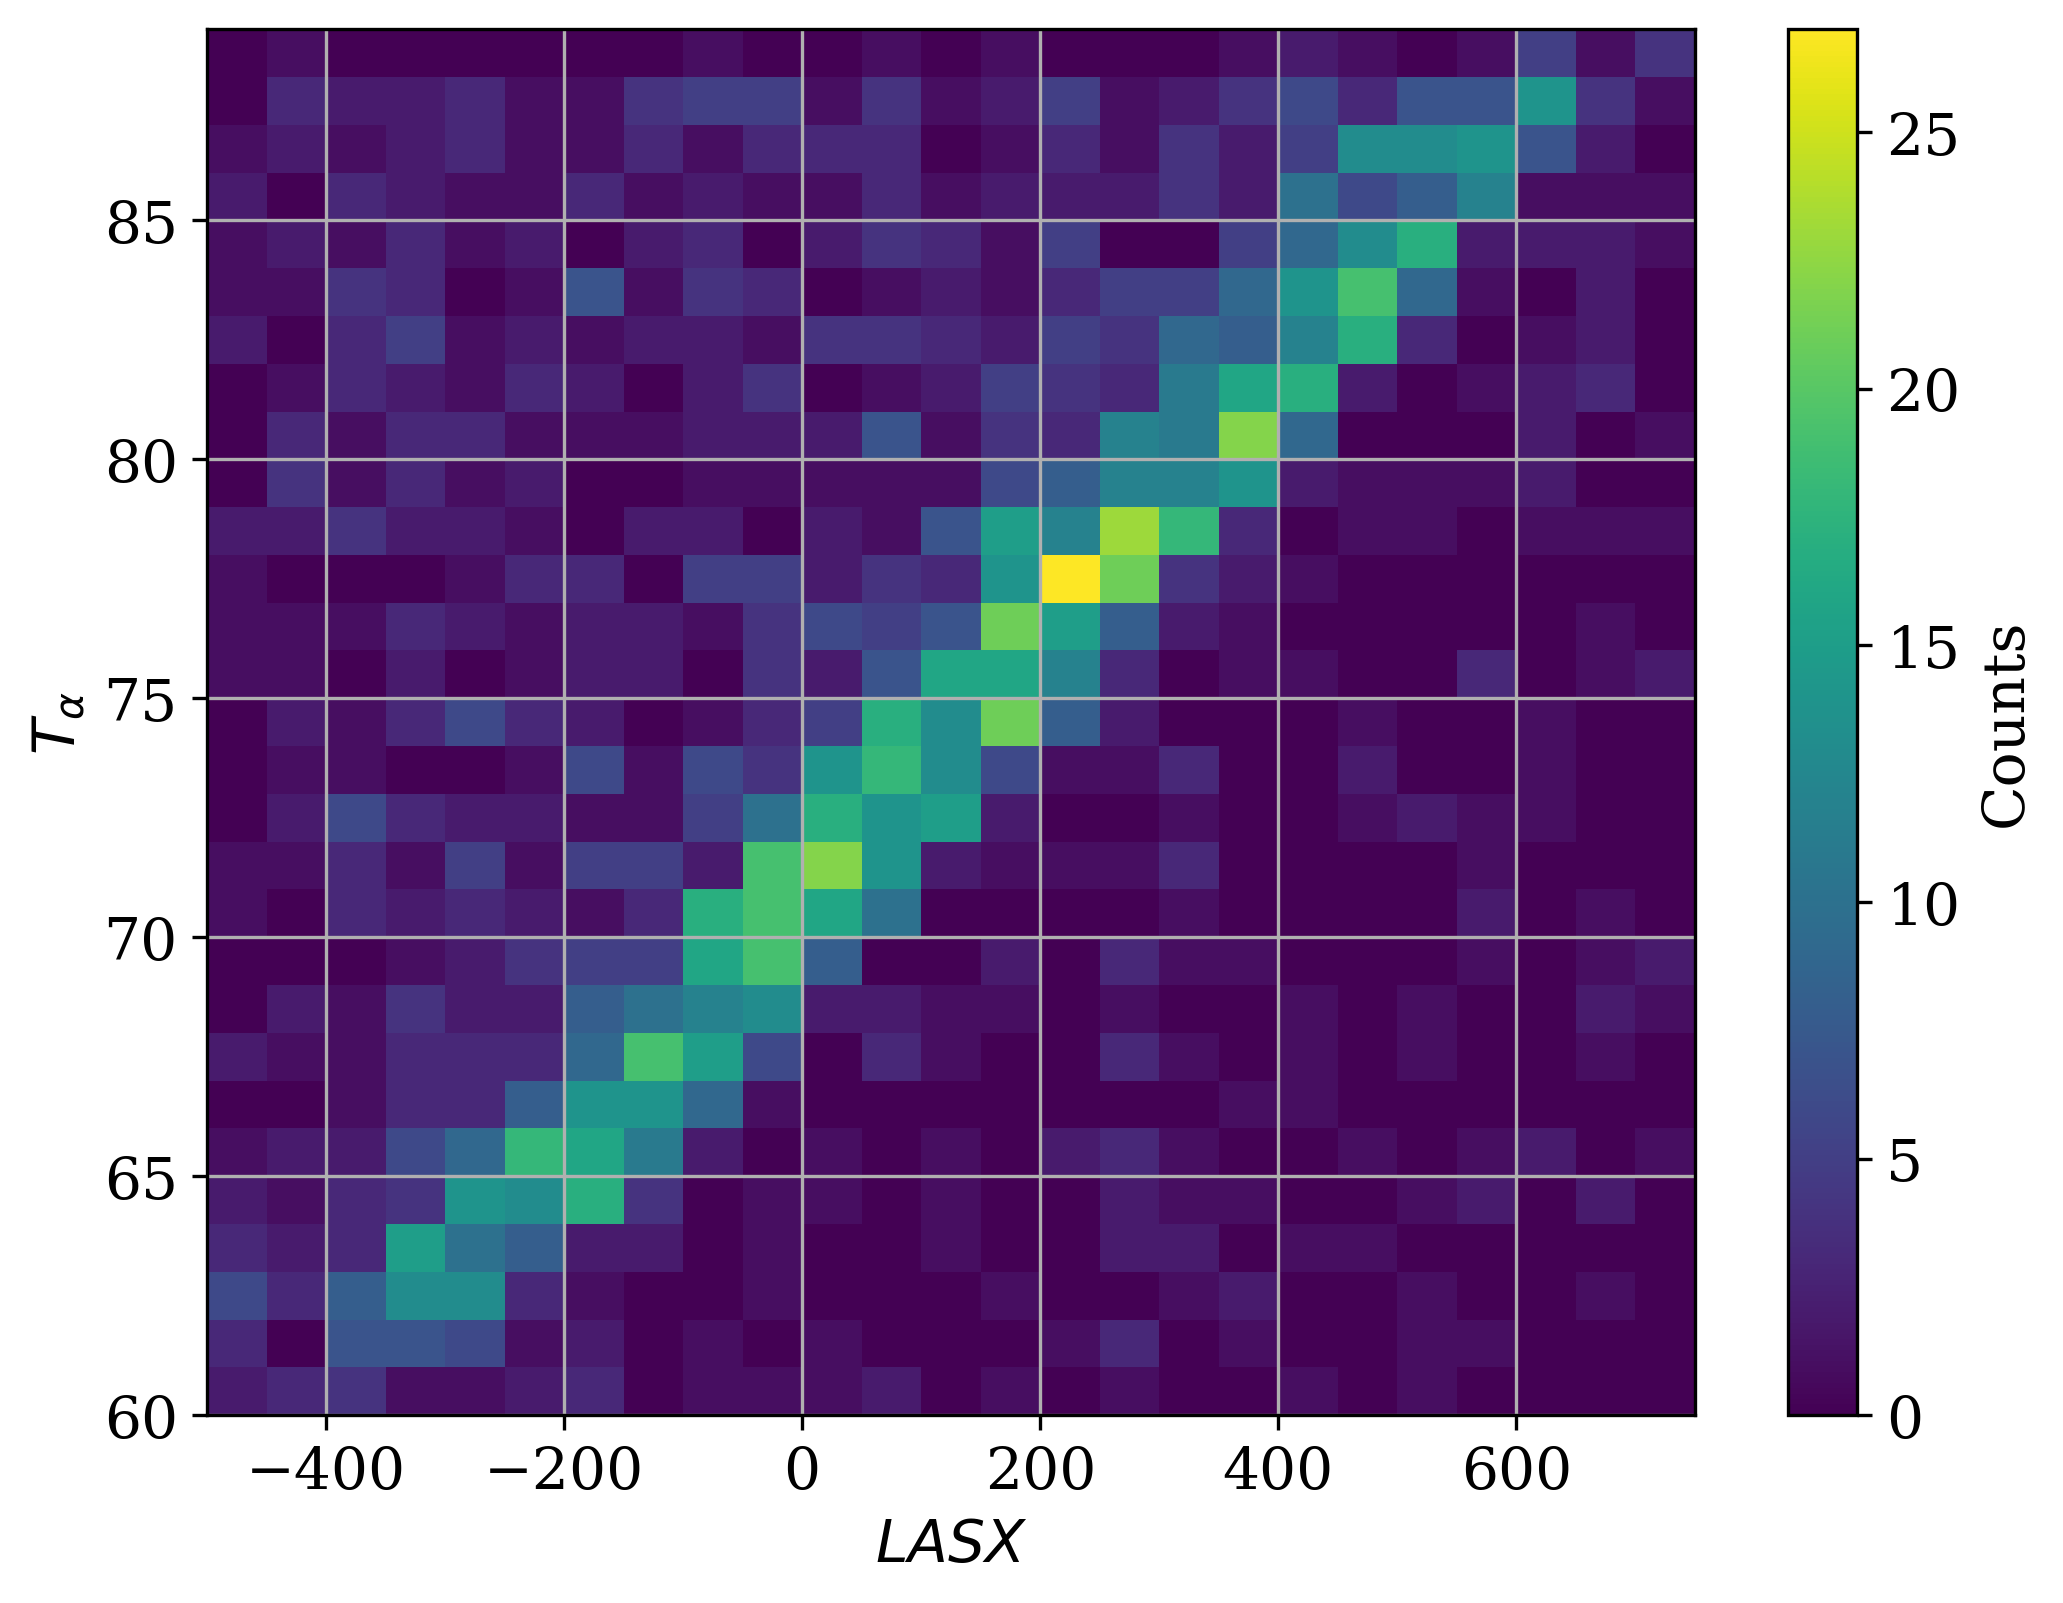

In [55]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=LASX_gated
y_axis_variable=T_alpha
#hist range
x_axis_range_min=-500
x_axis_range_max=800
y_axis_range_min=60
y_axis_range_max=90
#bin width
x_bin_width=50
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 1)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel(r'$LASX$')
ax.set_ylabel(r'$T_{\alpha}$')
ax.grid()

plt.show()

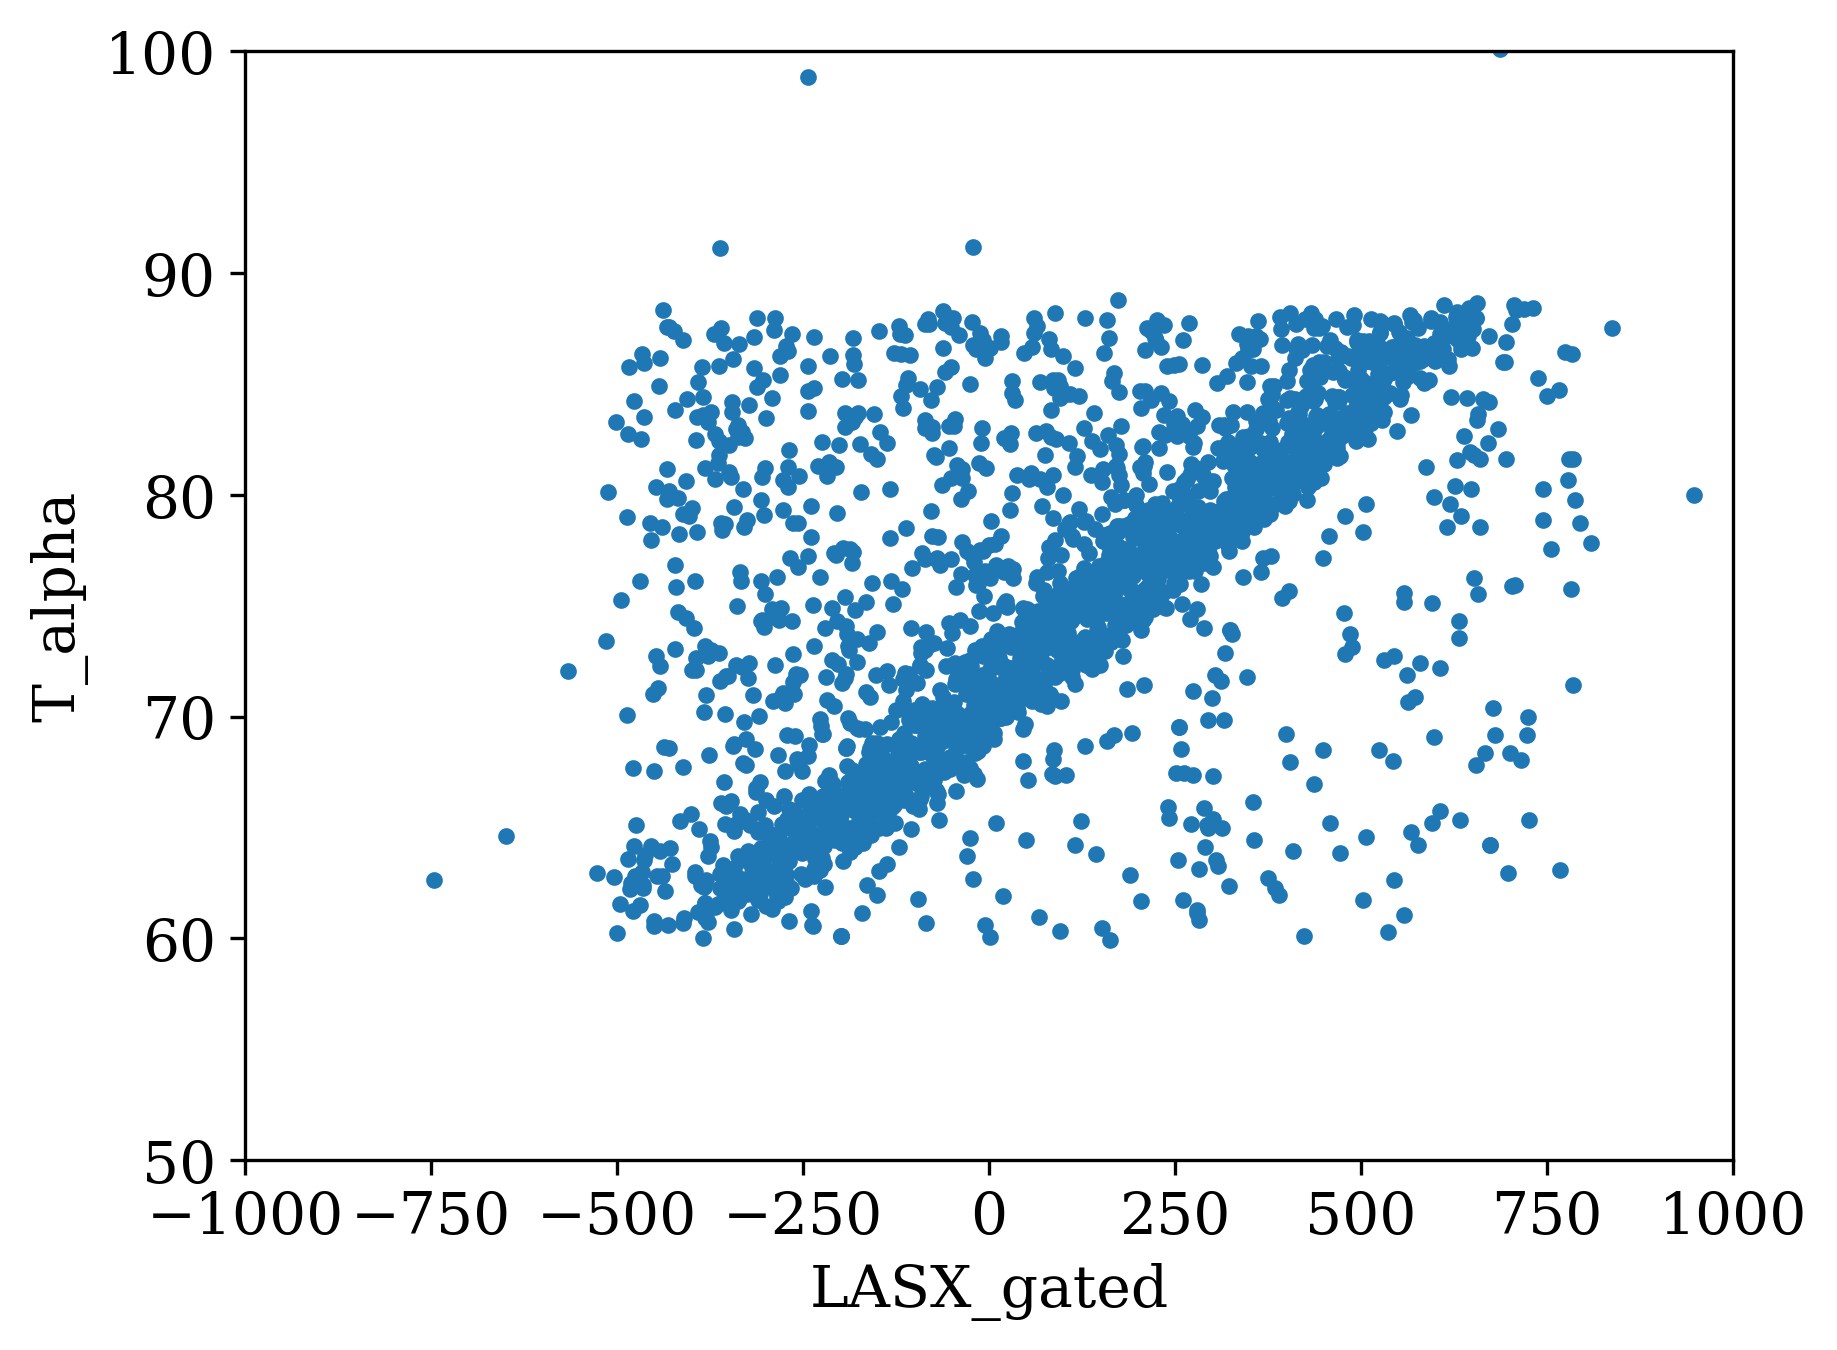

In [56]:
fig, ax = plt.subplots()
ax.plot(LASX_gated, T_alpha, '.')

# X軸の範囲を指定 (最小値, 最大値)
# 例: -500 から 1000 まで表示したい場合
ax.set_xlim(-1000, 1000)

# Y軸の範囲を指定 (最小値, 最大値)
# 例: 391.2 から 391.5 まで表示したい場合
ax.set_ylim(50, 100)

ax.set_xlabel('LASX_gated')
ax.set_ylabel('T_alpha')

plt.show()

In [57]:
gated_1 = gated[
    (LASX_gated >= -210) & (LASX_gated <= -190)
]
print(gated_1)
print(len(gated_1))

          iEve       GRX       GRA        GRY       GRB  GRQ2timing  \
12980    12980 -409.6180 -0.034837   5.049120  0.002536   338455.00   
42516    42516   24.0016  0.039117 -28.203300  0.001422   436169.00   
51546    51546 -409.3920 -0.035086   2.496150  0.001024    67704.60   
73016    73016 -354.8360  0.013442 -32.910500  0.002425   303481.00   
77241    77241 -579.9810  0.155395  -3.070660  0.095577   226673.00   
82376    82376 -384.8350 -0.043952   1.587840  0.000803   408554.00   
83042    83042 -312.8250 -0.013640  26.133800 -0.000369   505222.00   
98204    98204 -114.4340  0.008652   3.742290  0.002063   443214.00   
118463  118463 -356.2550  0.283481 -43.623800  0.628033   358070.00   
134412  134412  174.8270 -0.026283  -2.545640  0.001895   414133.00   
135331  135331  258.6110  0.042187  -5.301150  0.001174   117902.00   
156886  156886  356.9280  0.059077  13.911100 -0.002287   510592.00   
176200  176200 -242.9470  0.004738  21.744900  0.003038   391335.00   
182655

In [58]:
GRX_gated_1 = gated_1['GRX']

T_alpha_test = []
for n in GRX_gated_1:
    # T_alpha_test.append((392 - (((n * -0.0000454324 + 0.0017199490 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 0.515)
    T_alpha_test.append((392 - ((((n * -0.0000454324 + 0.0017199490 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 0.515))
print(T_alpha_test)

[64.44620350255592, 75.38409176186393, 64.4519349411829, 65.8345651720441, 60.11674646658945, 65.07451996155292, 66.89800007793802, 71.90498042244154, 65.79862645975423, 79.16067295075219, 81.25226388005068, 83.70087020007337, 68.66439636049368, 77.31110276998253, 74.32307874419631, 65.36450227992292, 65.57415209046768, 65.73026599704905, 63.47002756490552, 60.10070297767275, 66.28175657875191, 73.72775614413341, 65.666105867008, 85.21608724740405, 77.38879420623844, 64.35170627491708, 74.07634296473599, 65.13942651335638, 64.96441533635594, 64.57634499038555, 82.26502209694591, 66.46935141844106, 83.06686218164337, 77.61169408214197, 71.53281761683307, 65.16520045528146, 65.13255842225054, 72.35944858018216, 70.48748196923735, 71.73112857539978, 60.12362217288033, 64.87120757099056, 64.29996501115589, 67.78107466263792, 68.60069770875826, 68.60084925667603]


Text(0, 0.5, 'counts')

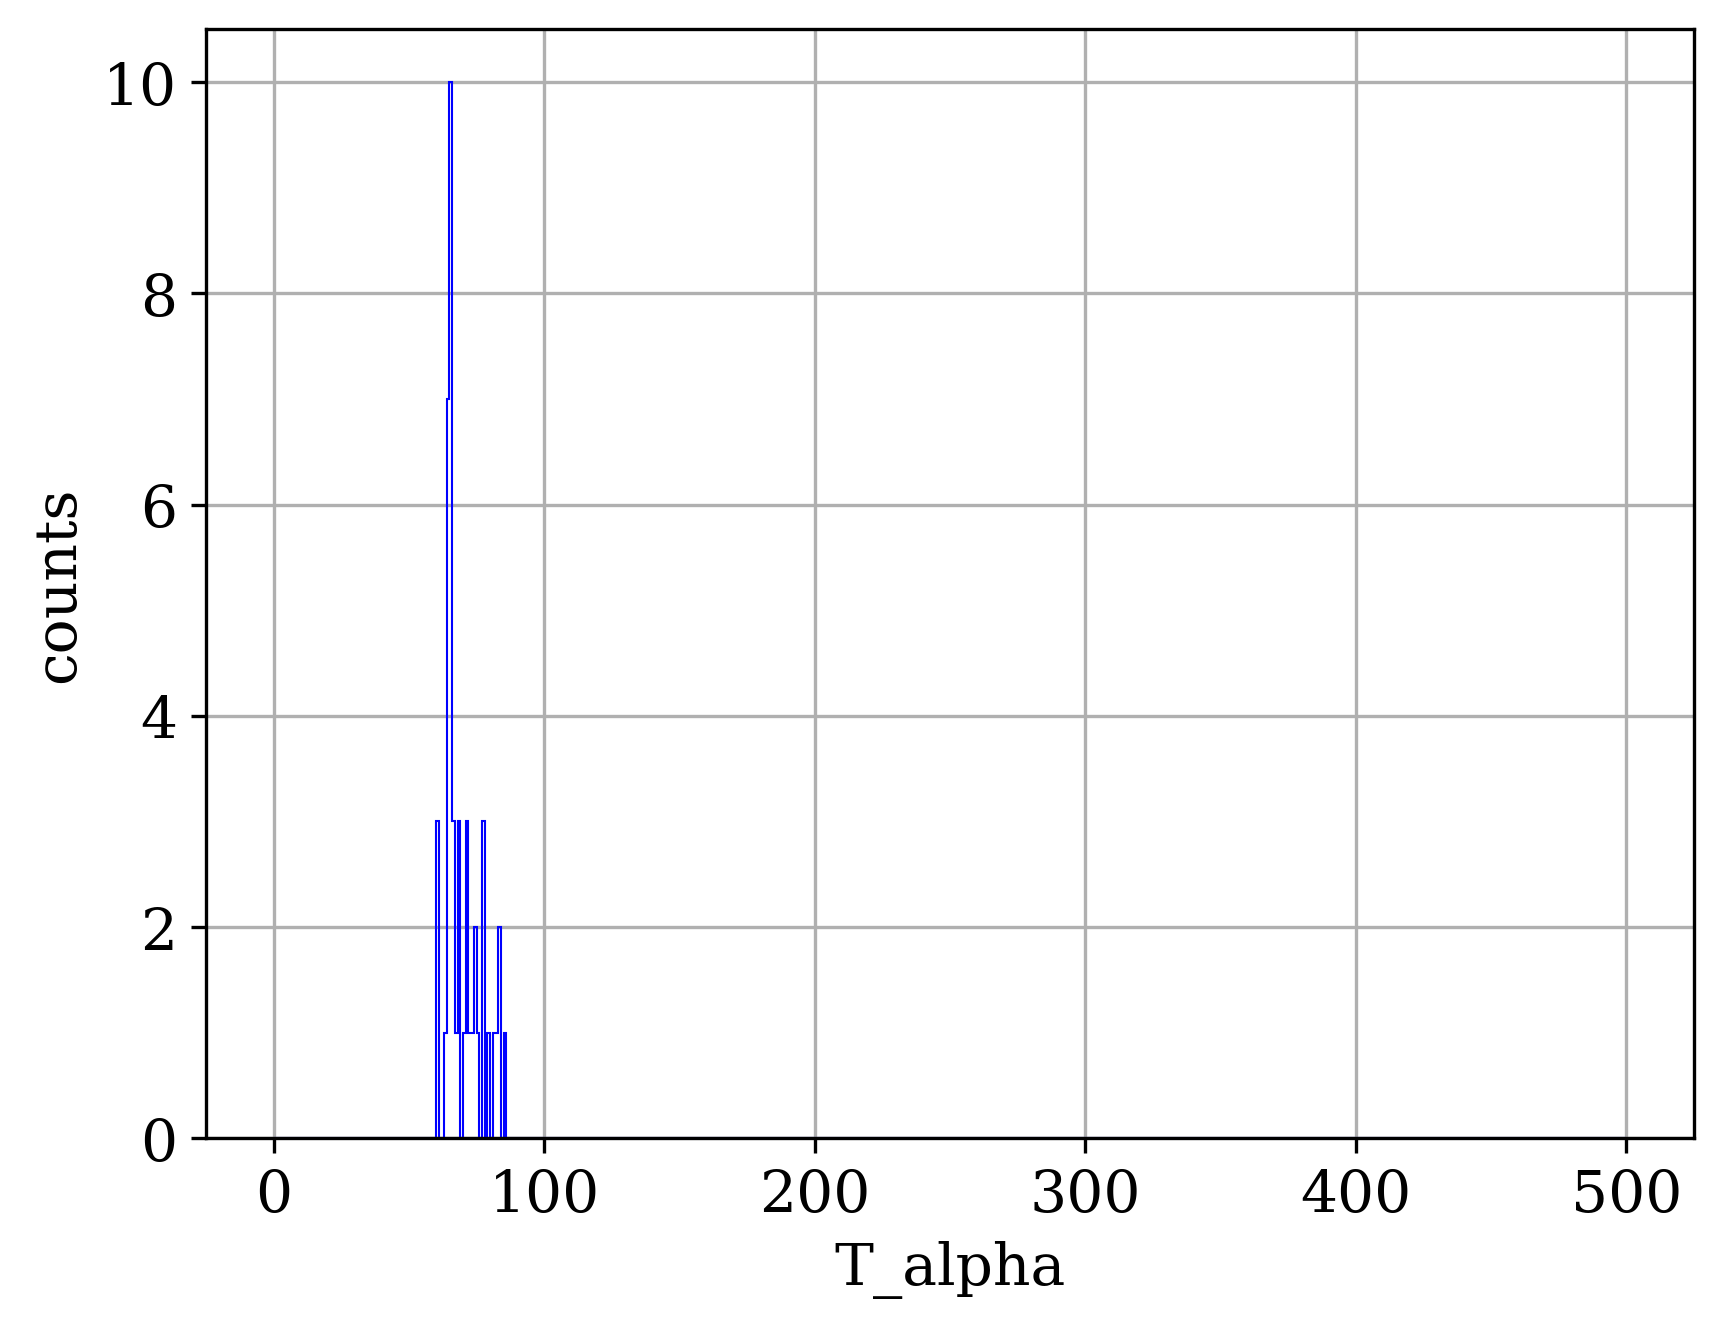

In [59]:
GRX_gated_1 = gated_1['GRX']

T_alpha_test = []
for n in GRX_gated_1:
    # T_alpha_test.append((392 - (((n * -0.0000454324 + 0.0017199490 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 0.515)
    T_alpha_test.append((392 - ((((n * -0.0000454324 + 0.0017199490 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 0.515))

variables = T_alpha_test

#hist range
range_min=0
range_max=500
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('T_alpha')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 21.183 ± 1.672
Mean: 66.423 ± 0.303
Sigma: 2.460 ± 0.215


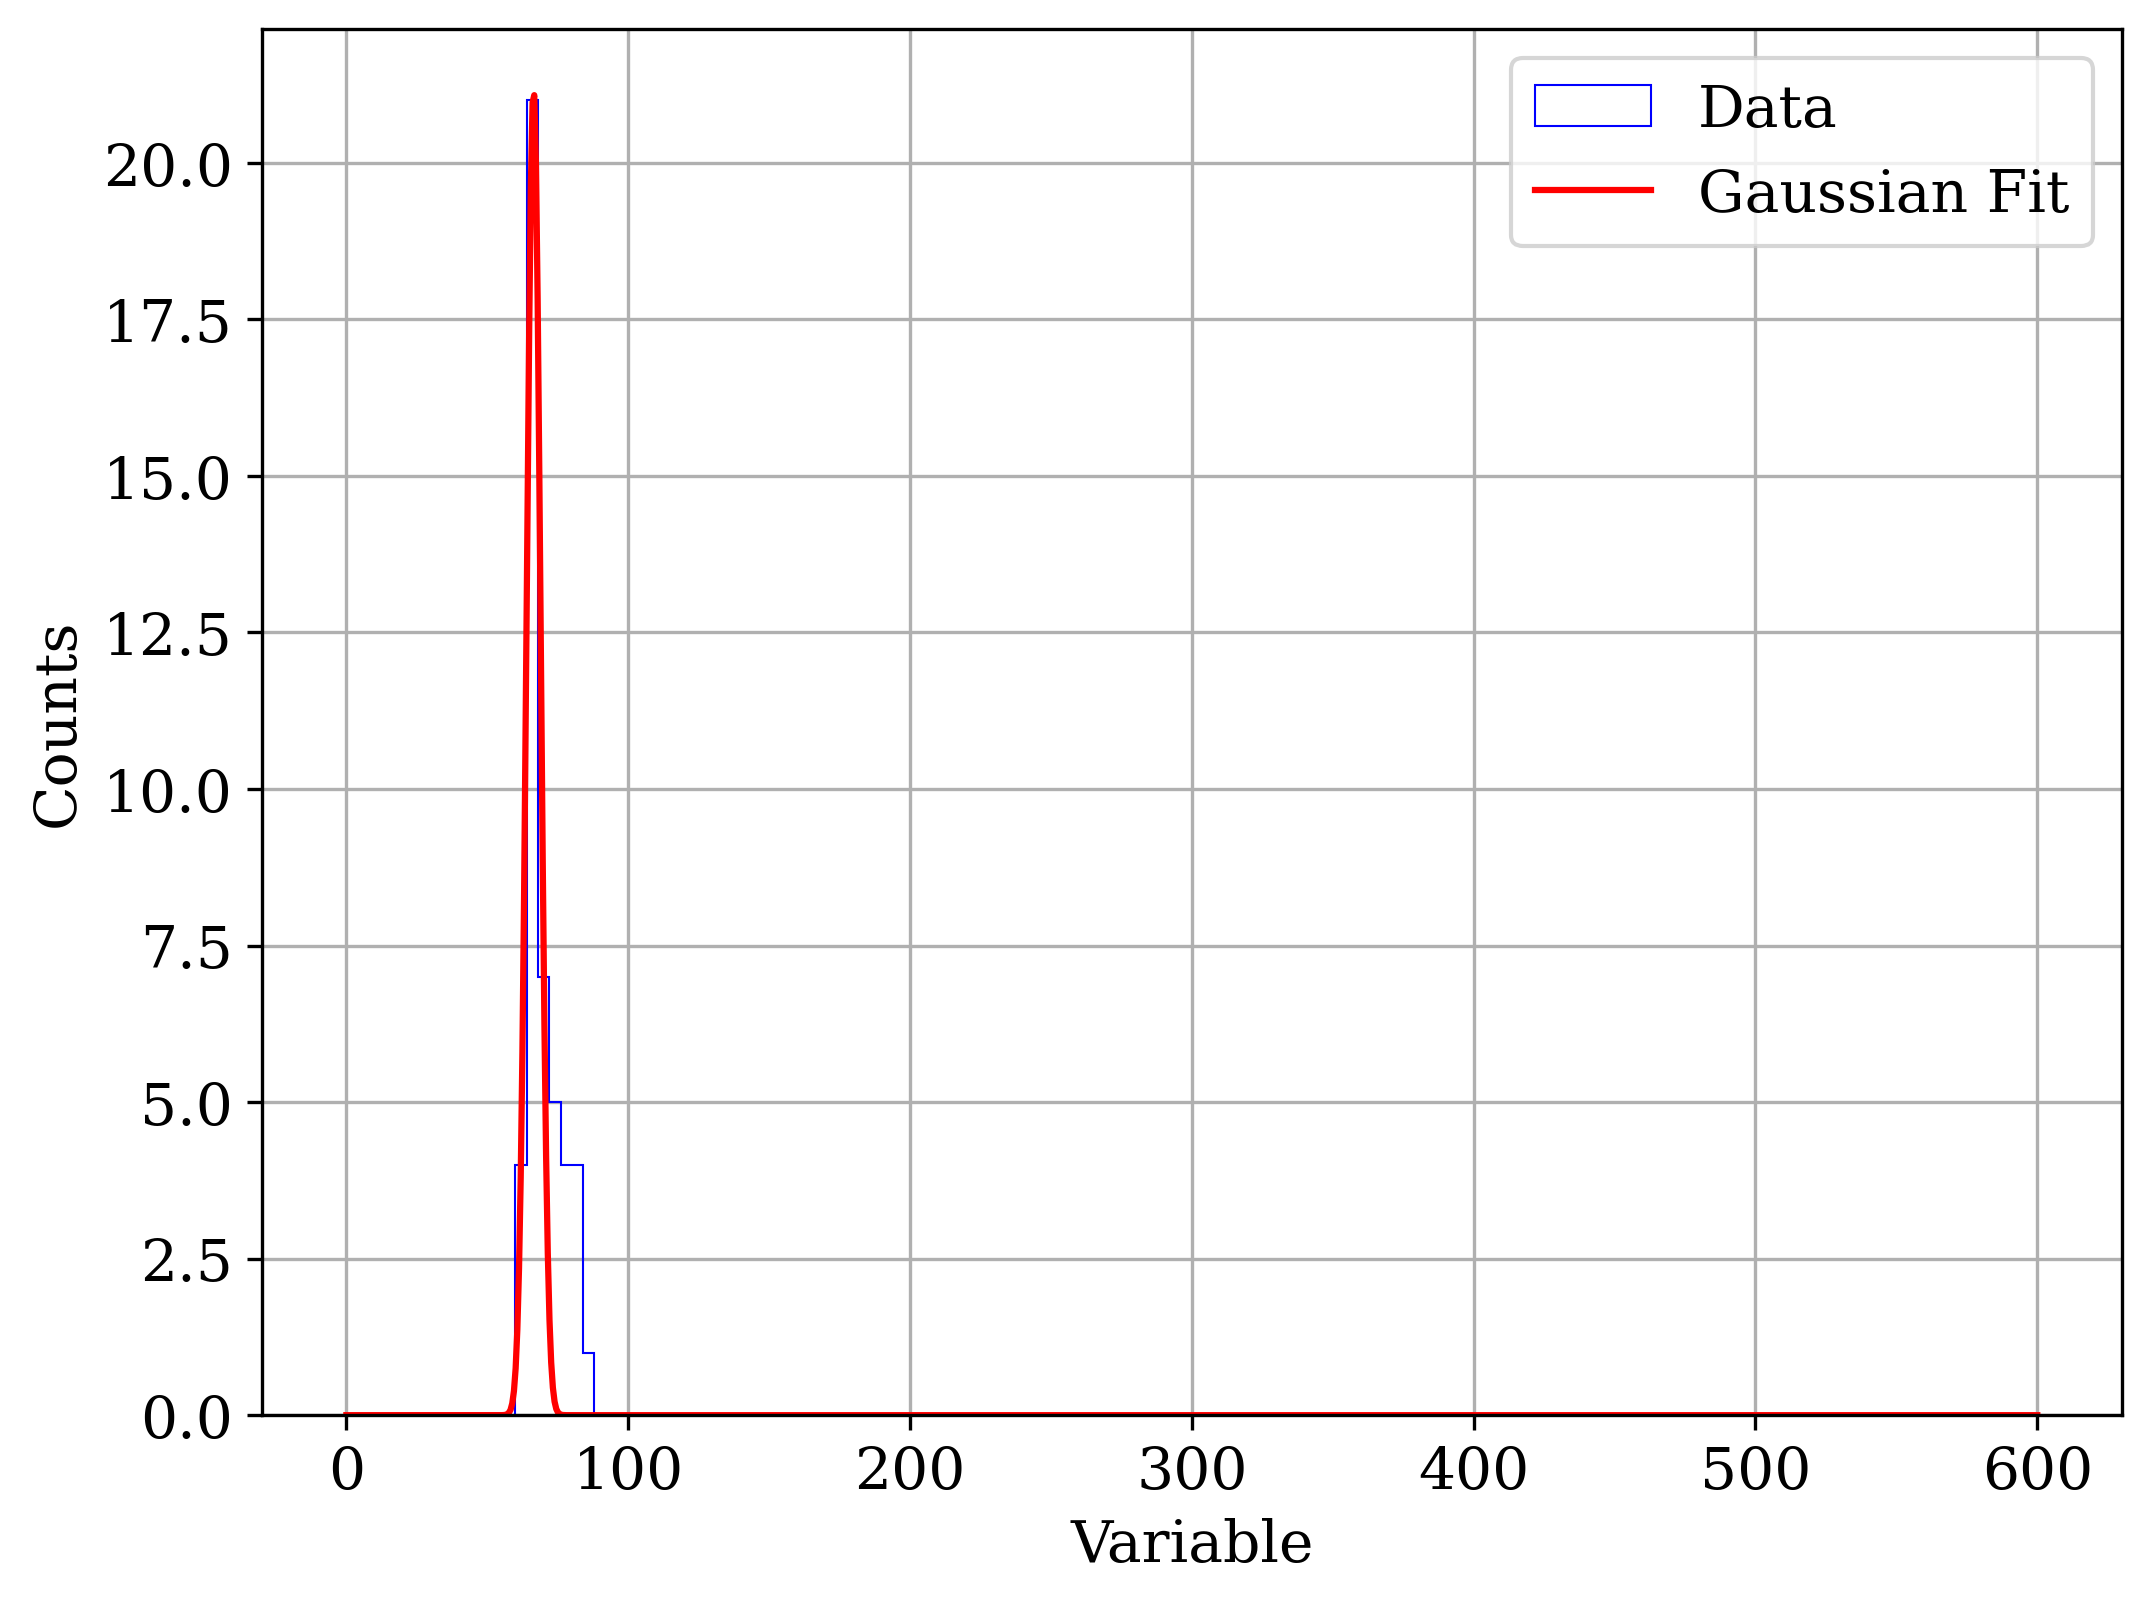

In [60]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = T_alpha_test
# Histogram range
hist_range_min = 0
hist_range_max = 600
# Bin width
bin_width = 4
# Fit range
fit_range_min = 0
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 10
mean = 50
sigma = 1
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

In [61]:
#gatedのLASXの値で絞り込む
gated_2 = gated[
    (LASX_gated >= 390) & (LASX_gated <= 410)
]

#gatedのGRXからT_alphaを求める
GRX_gated_2 = gated_2['GRX']

T_alpha_test2 = []
for n in GRX_gated_2:
    # T_alpha_test2.append((392 - (((n * -0.0000454324 + 0.0017199490 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 0.515)
    T_alpha_test2.append((392 - ((((n * -0.0000454324 + 0.0017199490 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27) - 0.515))
print(T_alpha_test2)
print(len(T_alpha_test2))

[63.92590540774823, 80.28848855787679, 84.27193931843668, 82.3763418049799, 67.97683639332023, 81.39658872019787, 81.14547749018844, 81.24184013505293, 83.23903479194779, 81.53947091313181, 80.37987009151594, 79.49332208135944, 81.25398453523154, 80.47189186916727, 80.03529086950367, 80.11561129819357, 75.35257366758502, 84.38789656519667, 88.01848092510191, 82.75591213741232, 85.15501942953448, 79.73936854151621, 88.1911137274643, 75.64614746171775, 80.55726685743353, 82.25214314832589, 80.61323940254475, 80.3159213984578, 69.21158060936442, 87.49734378272511, 83.44792468381671, 81.65134847071282, 81.66755069091083, 81.2339349708469, 61.97341341471598, 85.63548344522165, 82.03486887004907, 86.75634996794803]
38


Text(0, 0.5, 'counts')

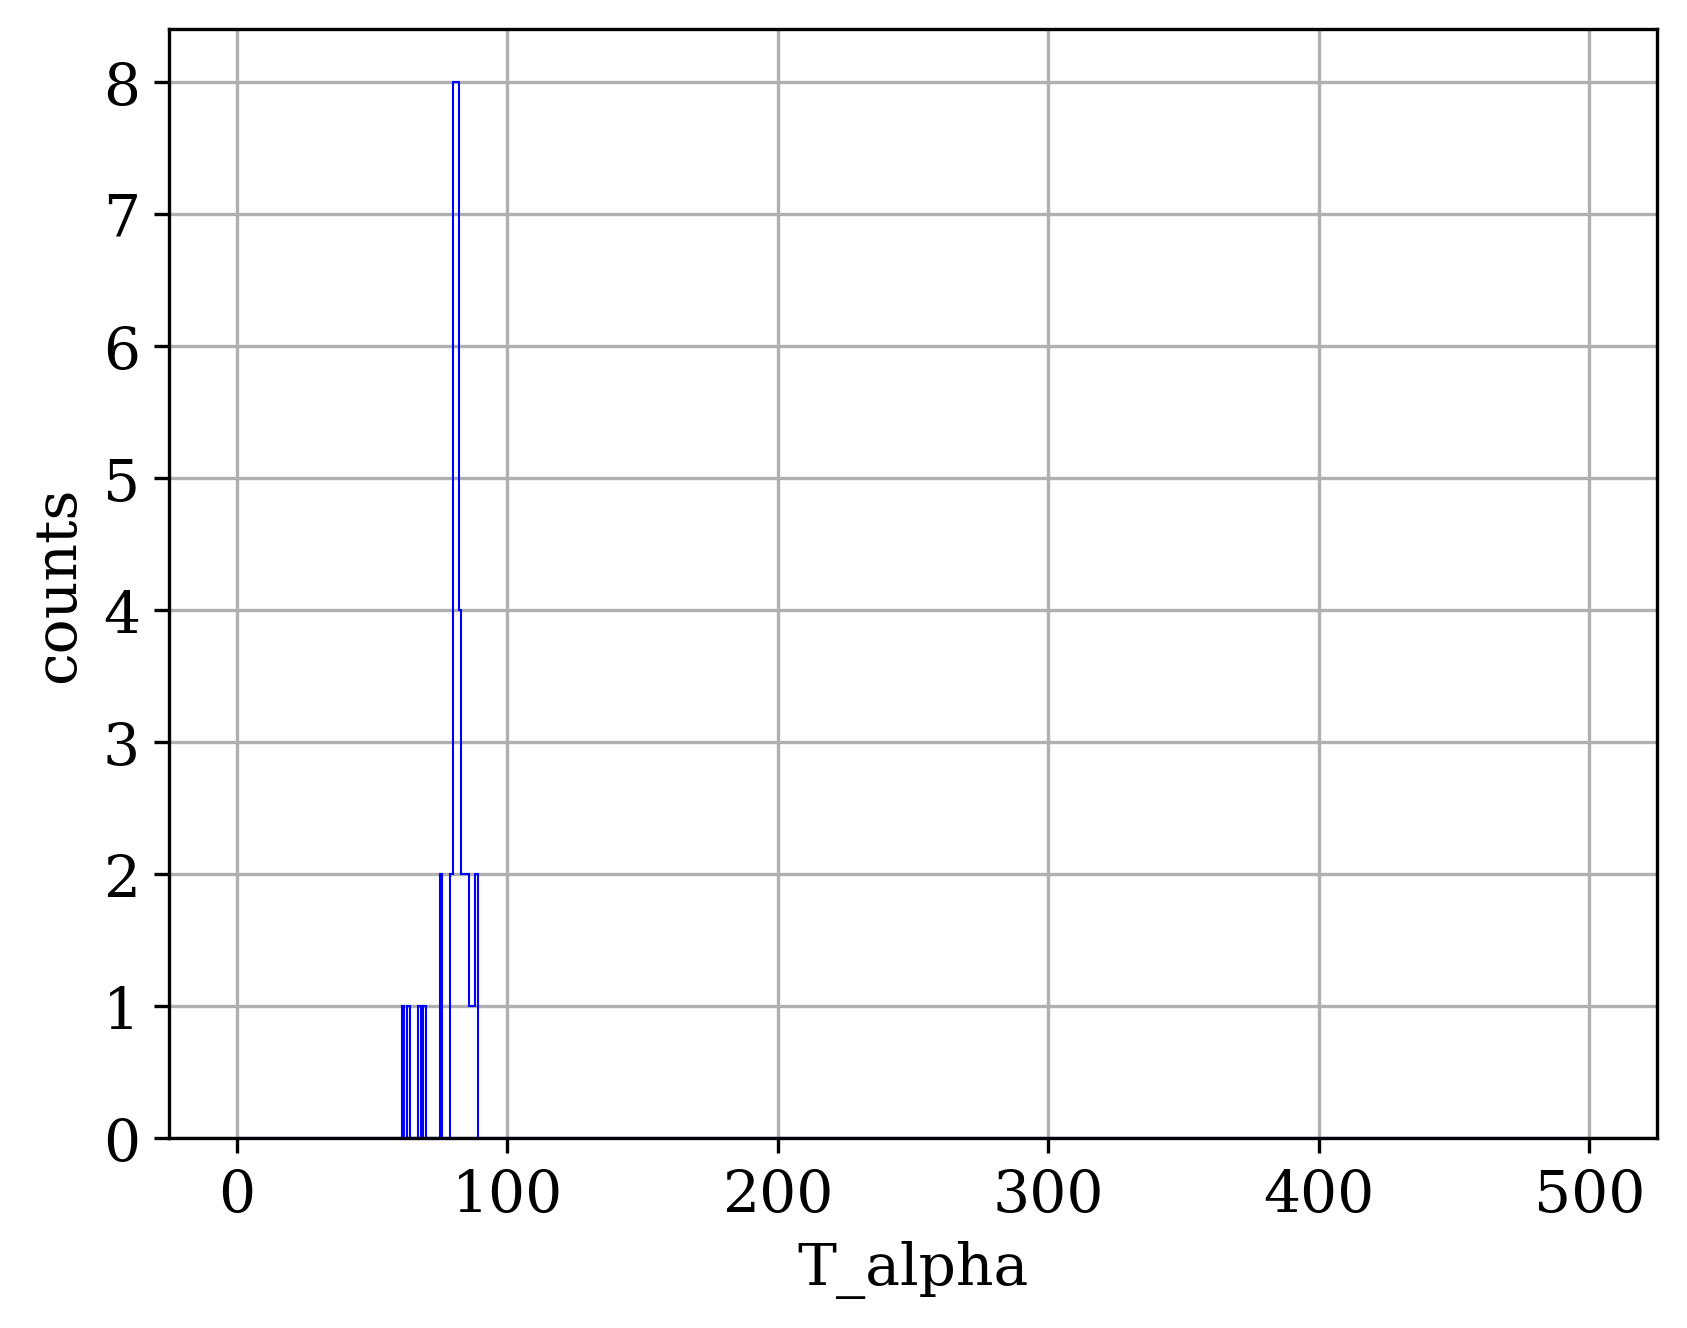

In [62]:
variables = T_alpha_test2

#hist range
range_min=0
range_max=500
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('T_alpha')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 22.878 ± 1.499
Mean: 82.589 ± 0.260
Sigma: 2.090 ± 0.175


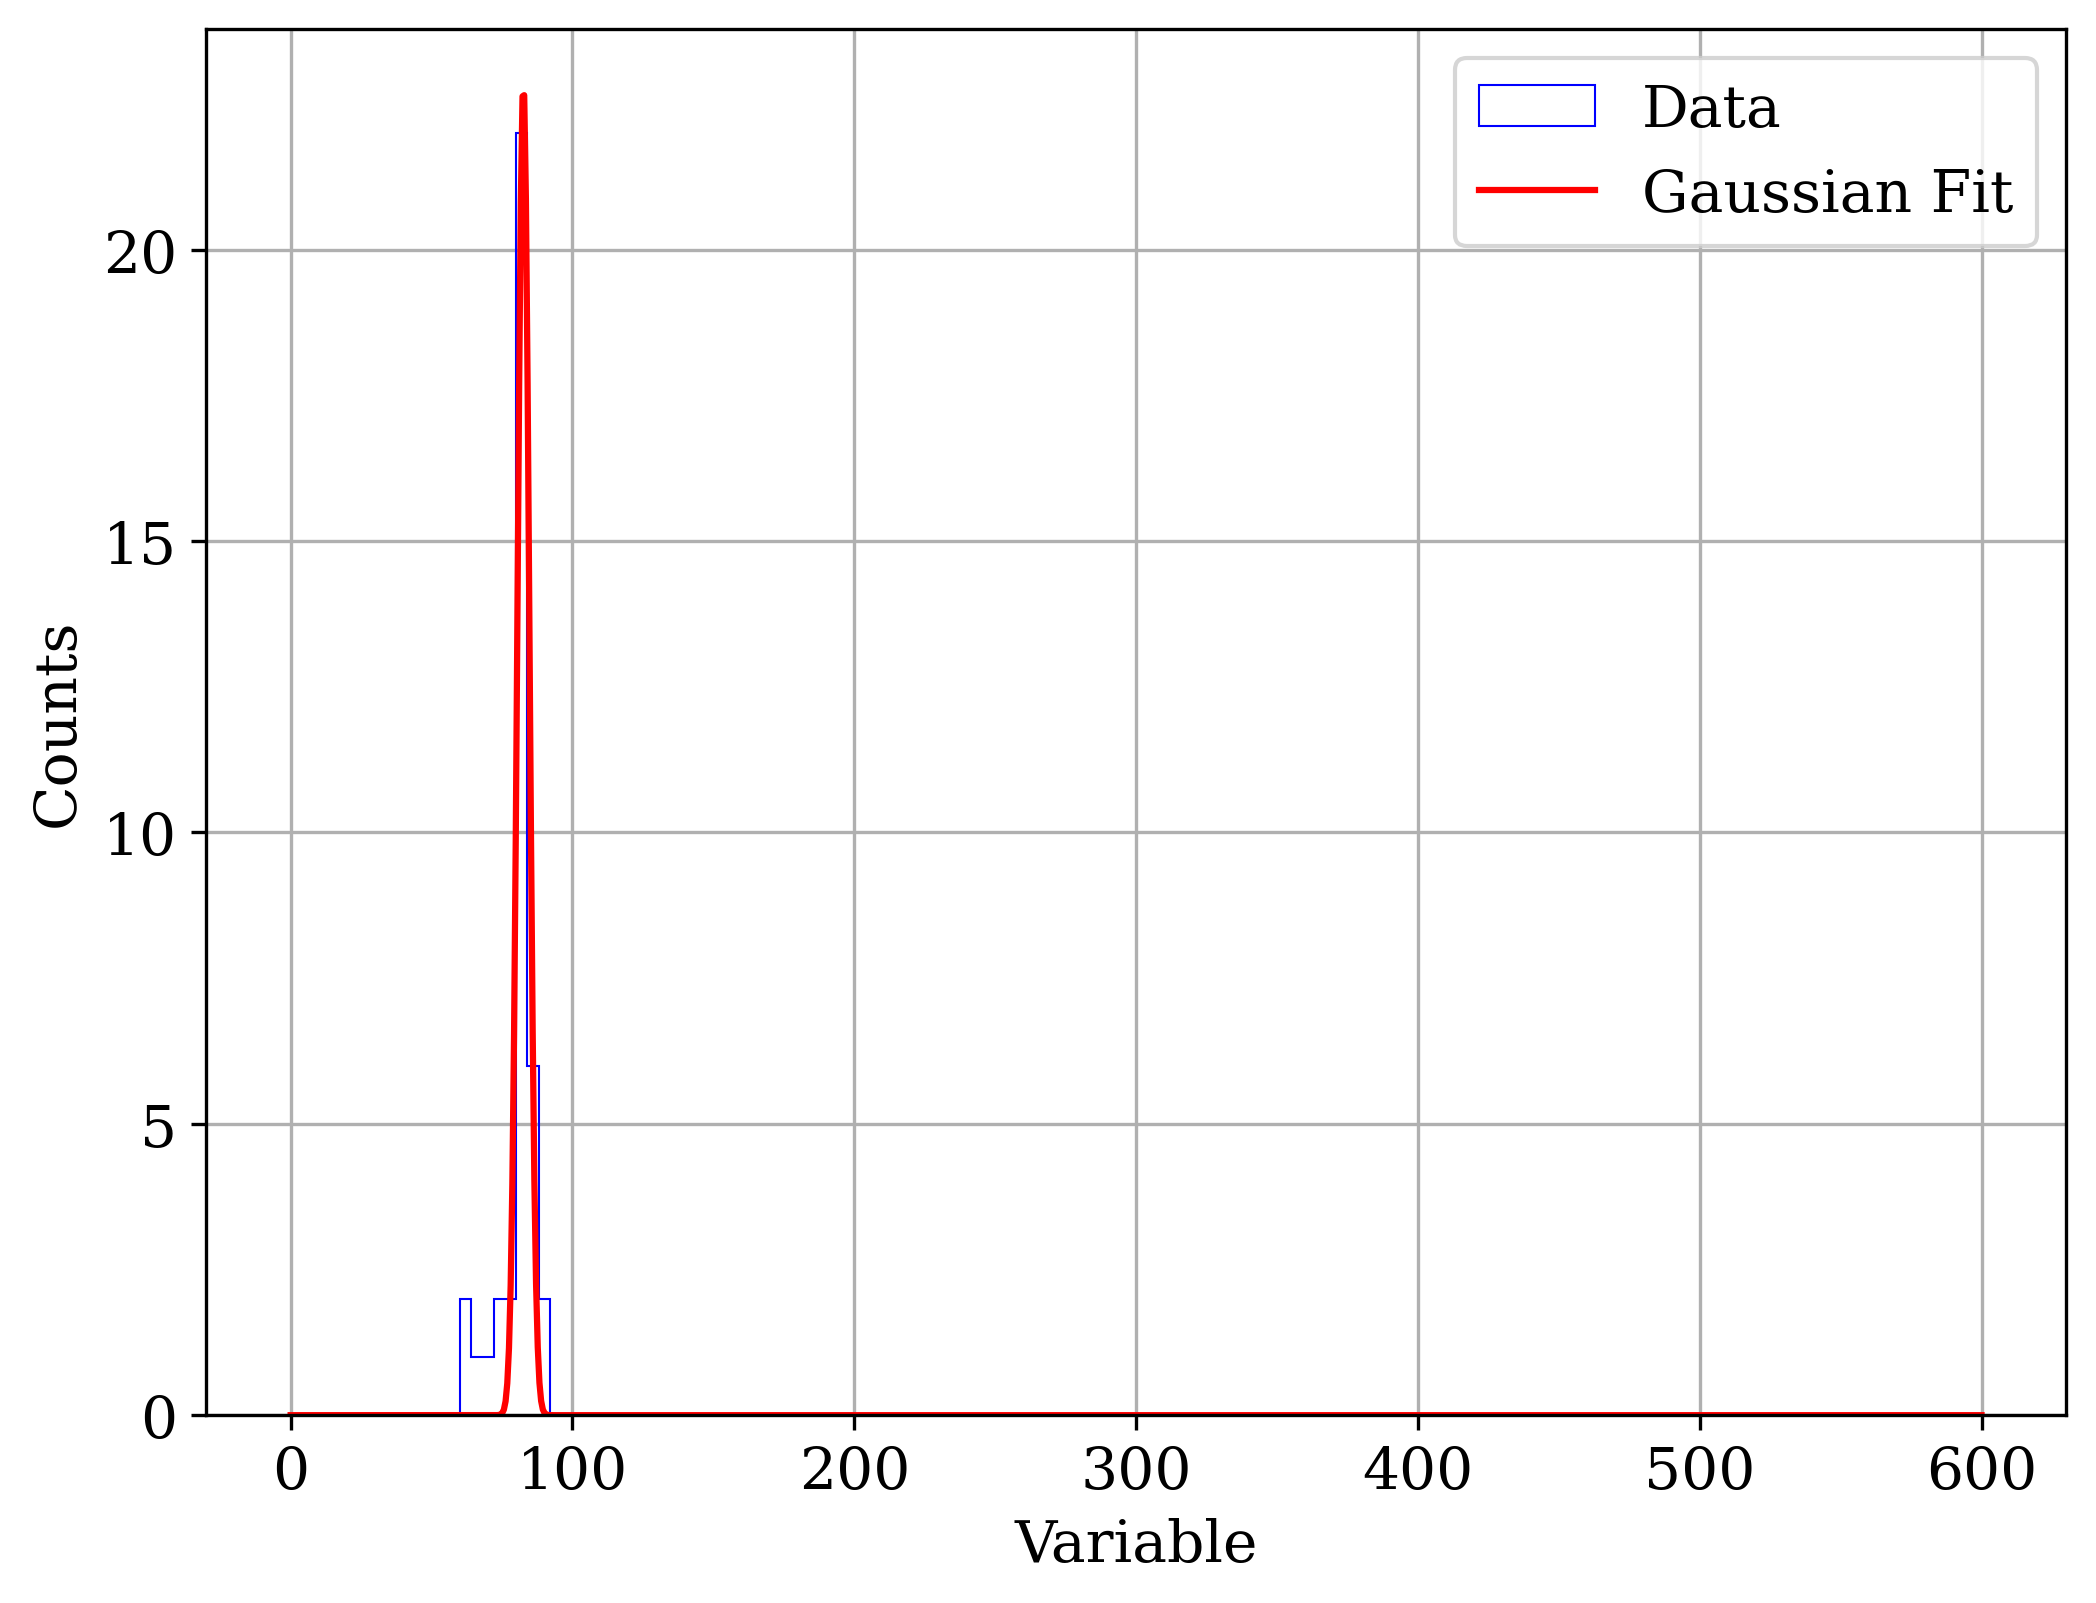

In [63]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = T_alpha_test2
# Histogram range
hist_range_min = 0
hist_range_max = 600
# Bin width
bin_width = 4
# Fit range
fit_range_min = 50
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 10
mean = 90
sigma = 1
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

Weighted linear fit: y_axsis_variable = 0.0269433333 * x_axsis_variable + 71.8116666667


/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1872/3614335151.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x_fit, y_fit_linear, 'r-', linewidth=2, label='Weighted Linear Fit', c='black')


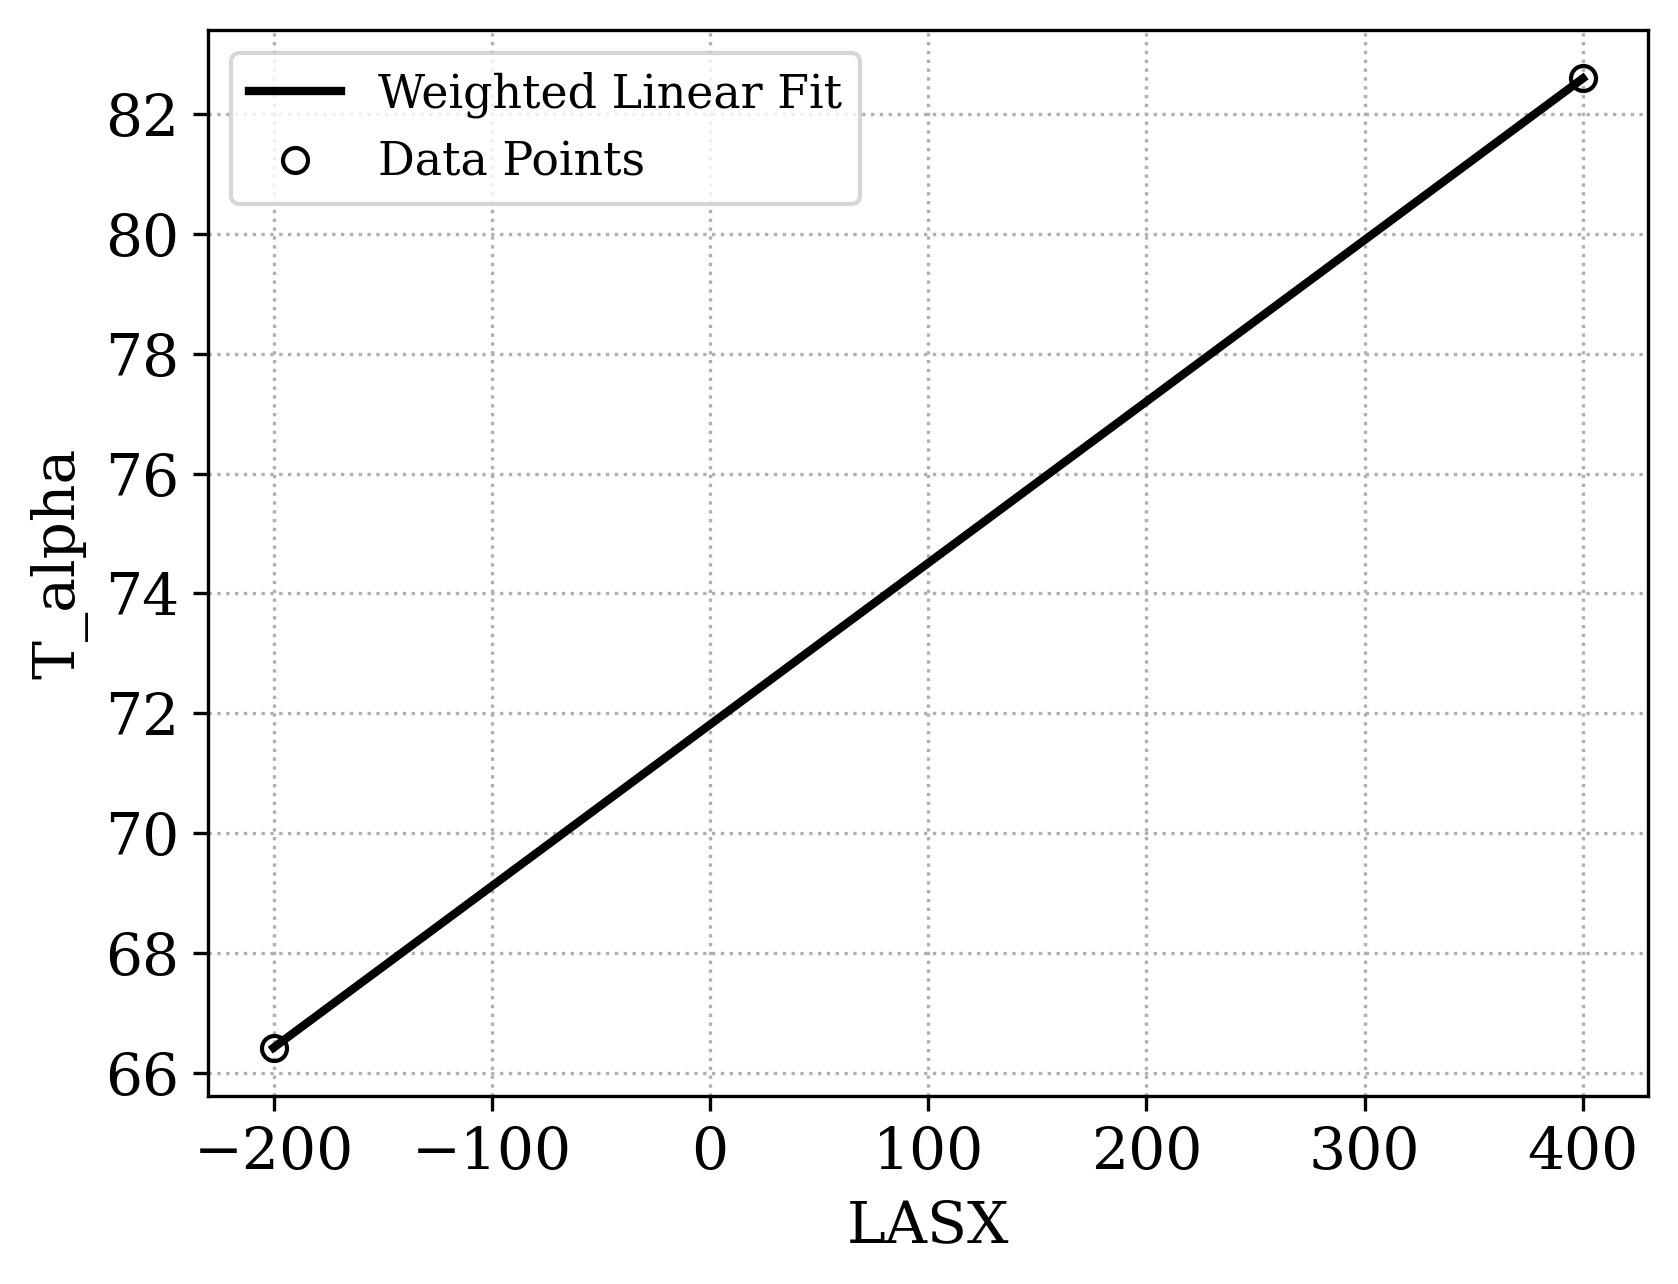

In [64]:
# # inpiut###############################
x_axis_variable = np.array([-200, 400])
y_axis_variable = np.array([66.423, 82.589])

# y_axis_variable = delta
# x_axis_variable = GRX_list


# hist_range_min=-0.011
# hist_range_max=0.0009
#######################################


# ---------- 線形フィット ----------
coefficients_linear = np.polyfit(x_axis_variable, y_axis_variable, 1)
fit_func_linear = np.poly1d(coefficients_linear)
a_linear, b_linear = coefficients_linear

print(f"Weighted linear fit: y_axsis_variable = {a_linear:.10f} * x_axsis_variable + {b_linear:.10f}")

# ---------- 描画用 ----------
x_fit = np.linspace(min(x_axis_variable), max(x_axis_variable),1001)
y_fit_linear = fit_func_linear(x_fit)

plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(6, 4.5))

# フィット直線
ax.plot(x_fit, y_fit_linear, 'r-', linewidth=2, label='Weighted Linear Fit', c='black')

# エラーバー付きデータ点
ax.errorbar(x_axis_variable, y_axis_variable,
            fmt='o', markersize=6,
            capsize=4, capthick=1,
            markerfacecolor='none',       # 中を白抜き
            markeredgecolor='black',     # 枠線を黒に
            ecolor='gray',               # エラーバーの色
            label='Data Points')

# 軸ラベル
ax.set_xlabel('LASX')
ax.set_ylabel('T_alpha')

# グリッド・凡例
ax.grid(True, linestyle=':')
ax.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()

In [65]:
GRX_gated = gated['GRX']
LASX_gated = gated['LASX']
 
T_alpha = []
for n in LASX_gated:
    T_alpha.append(0.0269433333 * n + 71.8116666667 - 6.85) #7.89は鉛と炭素の間違いを訂正するためのもの。

# T_alpha = []
# for n in LASX_gated:
#     T_alpha.append(0.0269433333 * n + 71.8116666667)

print(T_alpha)

[69.86476057396742, 69.08817287826152, 74.8264831744956, 68.87925427185331, 64.98872612576653, 77.96977326727351, 58.6754636878104, 76.25008807606771, 56.1855224842242, 68.71285224539251, 64.1728089770093, 132.08559291699, 72.76938662037391, 55.543031758352406, 61.28778151124521, 72.33999071757181, 72.34158037423651, 53.59888165742431, 74.4242192083266, 56.001795894451504, 74.79552528453391, 61.84936140721711, 58.8749251842303, 71.73166413832442, 70.57078367976061, 66.25858401509551, 71.98592837467652, 70.59761923972741, 72.43235246412421, 75.18790104738181, 55.2418052920584, 57.24350635291531, 72.66320294383861, 63.963841872601144, 69.60276360095821, 58.6322465811972, 79.11427217919092, 60.96540452831071, 67.33482199209736, 76.35697227926882, 62.53279252803825, 77.83408664077471, 63.69433848693456, 68.98508768505572, 56.715147586902305, 75.0262410475818, 81.38381691638311, 62.51282482372962, 57.416186176035005, 79.04322260927881, 64.27935638854414, 62.85143516497738, 62.29344681533437

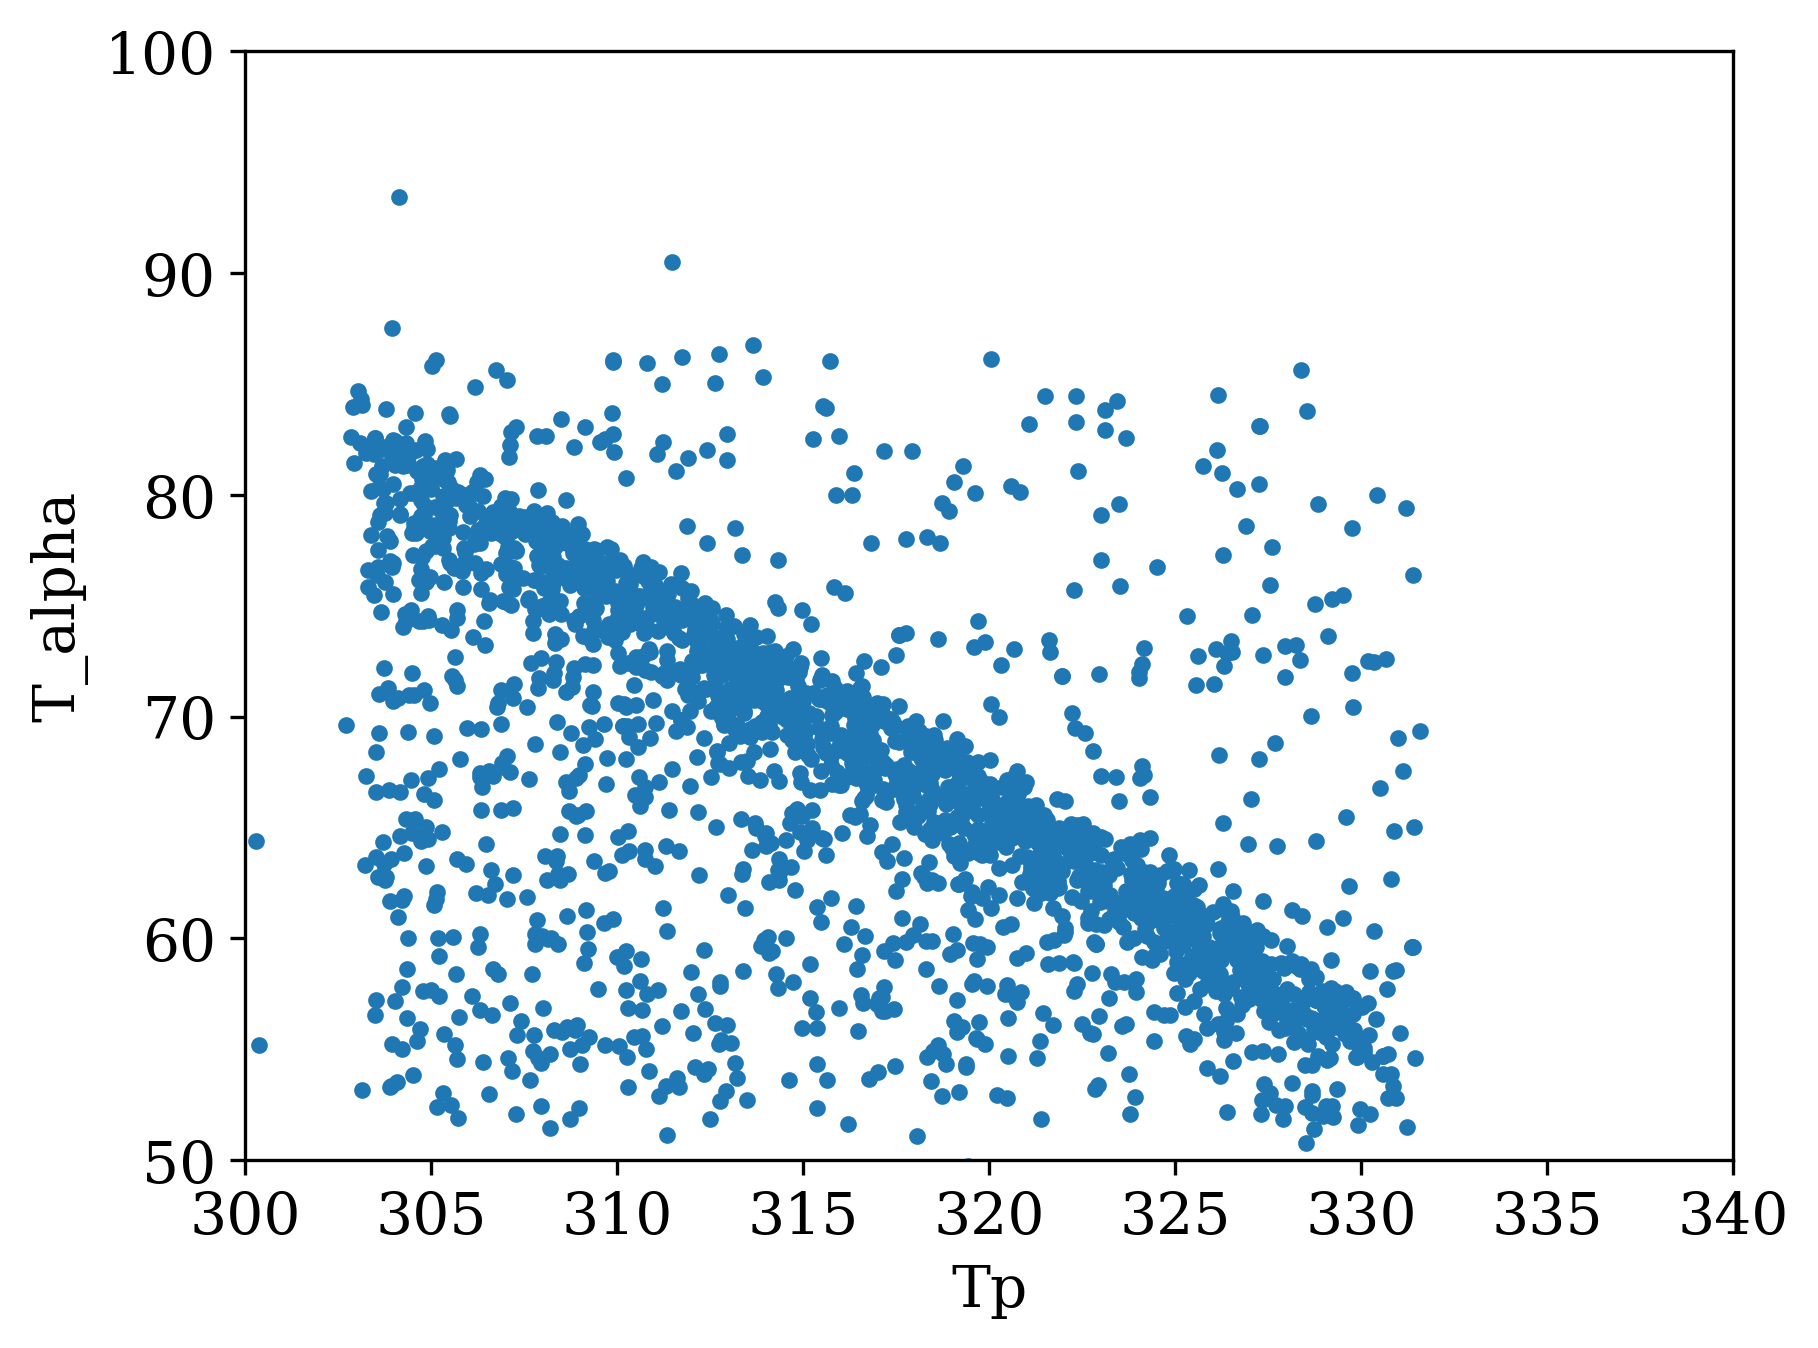

In [66]:
fig, ax = plt.subplots()
ax.plot(Tp, T_alpha, '.')

# X軸の範囲を指定 (最小値, 最大値)
# 例: -500 から 1000 まで表示したい場合
ax.set_xlim(300, 340)

# Y軸の範囲を指定 (最小値, 最大値)
# 例: 391.2 から 391.5 まで表示したい場合
ax.set_ylim(50, 100)

ax.set_xlabel('Tp')
ax.set_ylabel('T_alpha')

plt.show()

最適化された傾き: 2.69e-02
最適化された切片: 64.96


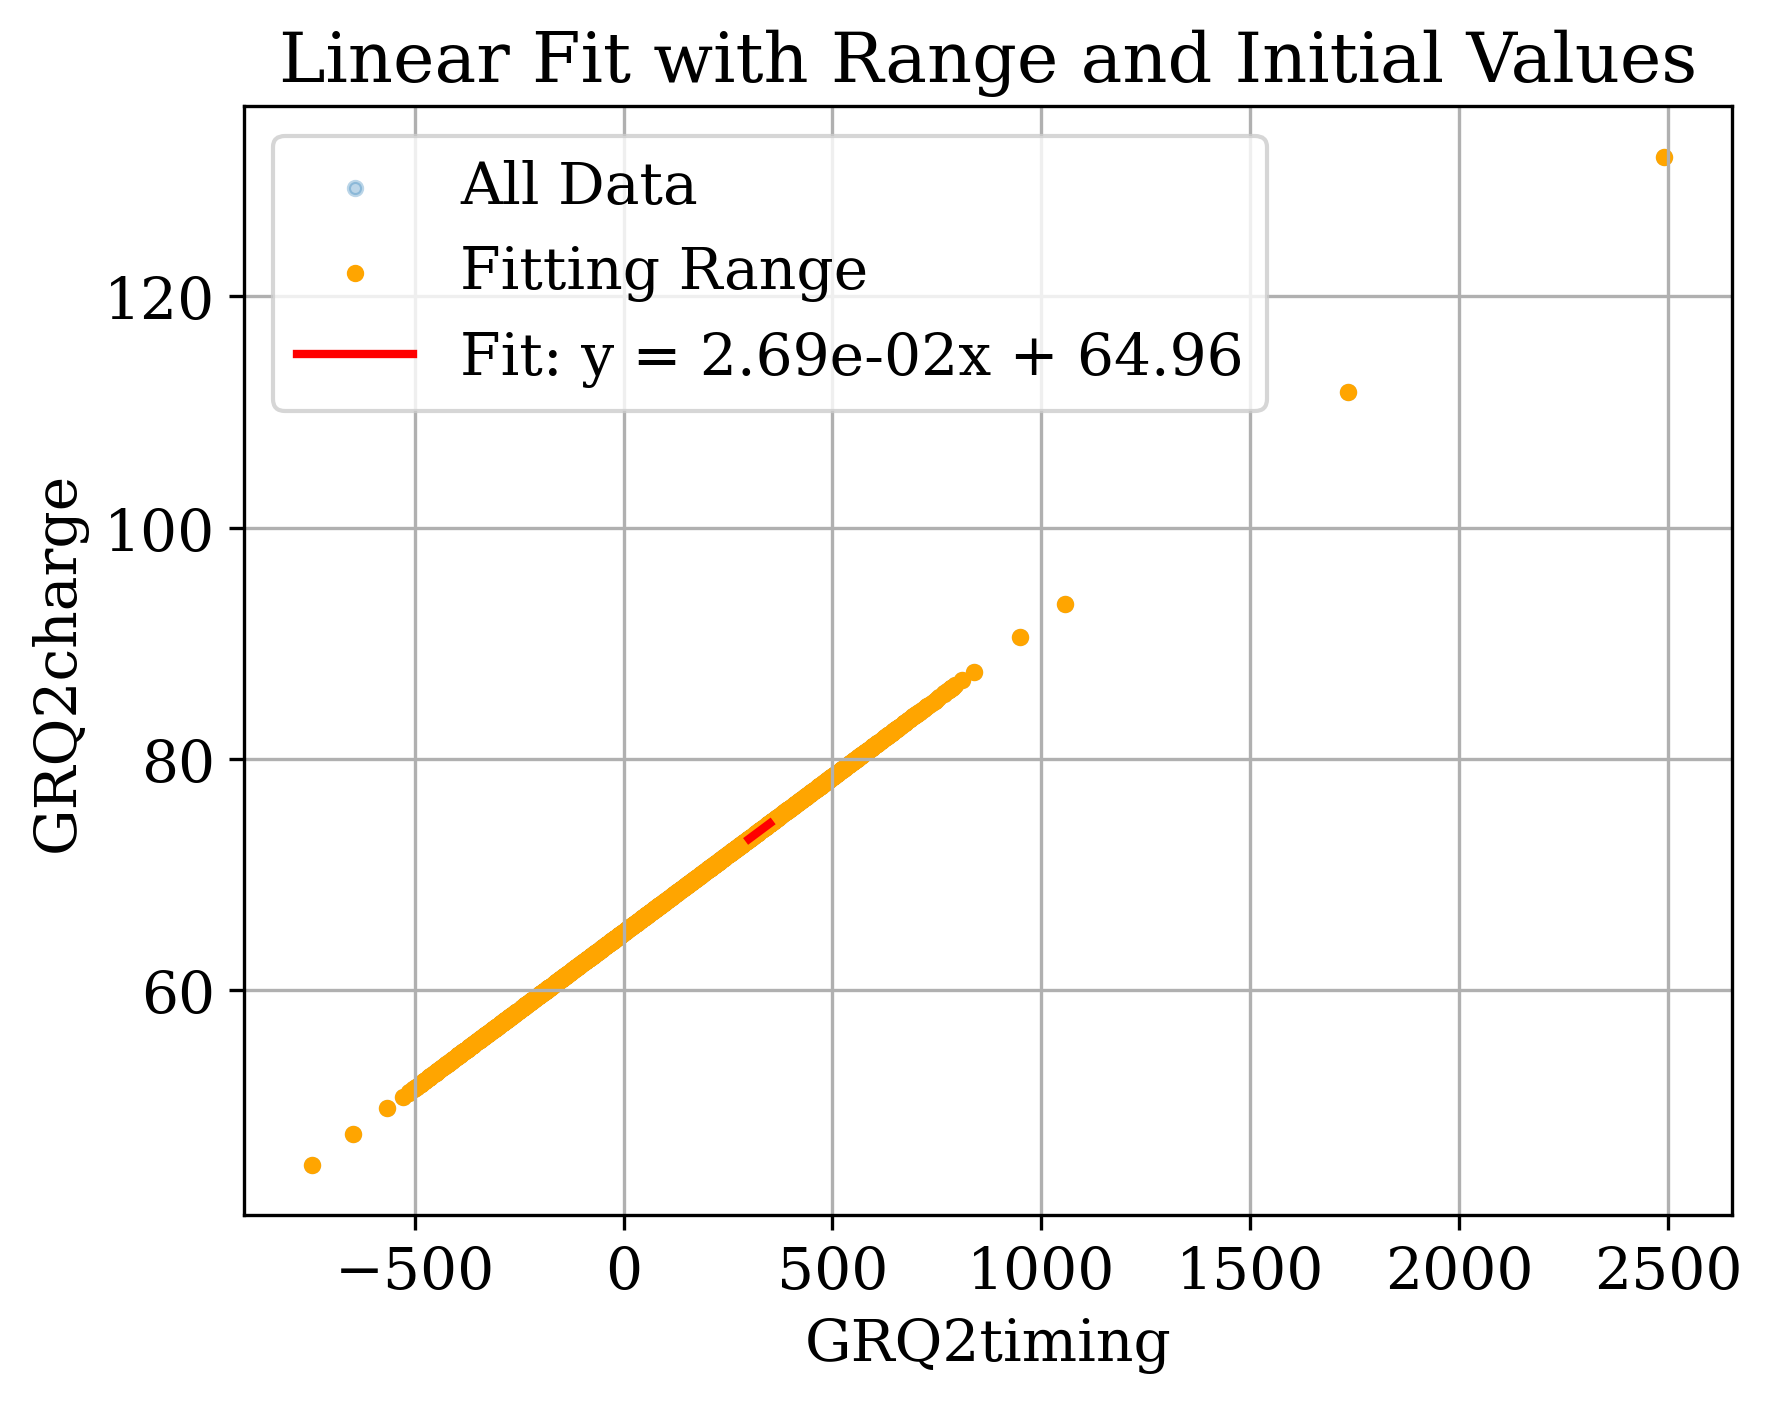

In [67]:
# 1. フィッティング関数の定義 (y = ax + b)
def linear_func(x, a, b):
    return a * x + b

# 2. フィッティング範囲と初期値の指定
x_min, x_max = 300, 350  # x軸（timing）の範囲を指定
initial_guess = [1, 1]  # [傾きaの初期値, 切片bの初期値]

# 3. データのフィルタリング

x_data = LASX_gated
y_data = T_alpha

# 4. フィッティングの実行
# p0: 初期値, bounds: パラメータの探索範囲（必要なら設定可）
popt, pcov = curve_fit(linear_func, x_data, y_data, p0=initial_guess)

# 最適化されたパラメータの取得
best_a, best_b = popt
print(f"最適化された傾き: {best_a:.2e}")
print(f"最適化された切片: {best_b:.2f}")

# 5. プロット
plt.scatter(x_data, y_data, s=10, alpha=0.3, label='All Data')
plt.scatter(x_data, y_data, s=10, color='orange', label='Fitting Range') # 範囲内の点

x_fit = np.linspace(x_min, x_max, 100)
y_fit = linear_func(x_fit, *popt)
plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Fit: y = {best_a:.2e}x + {best_b:.2f}')

plt.title('Linear Fit with Range and Initial Values')
plt.xlabel('GRQ2timing')
plt.ylabel('GRQ2charge')
plt.legend()
plt.grid(True)

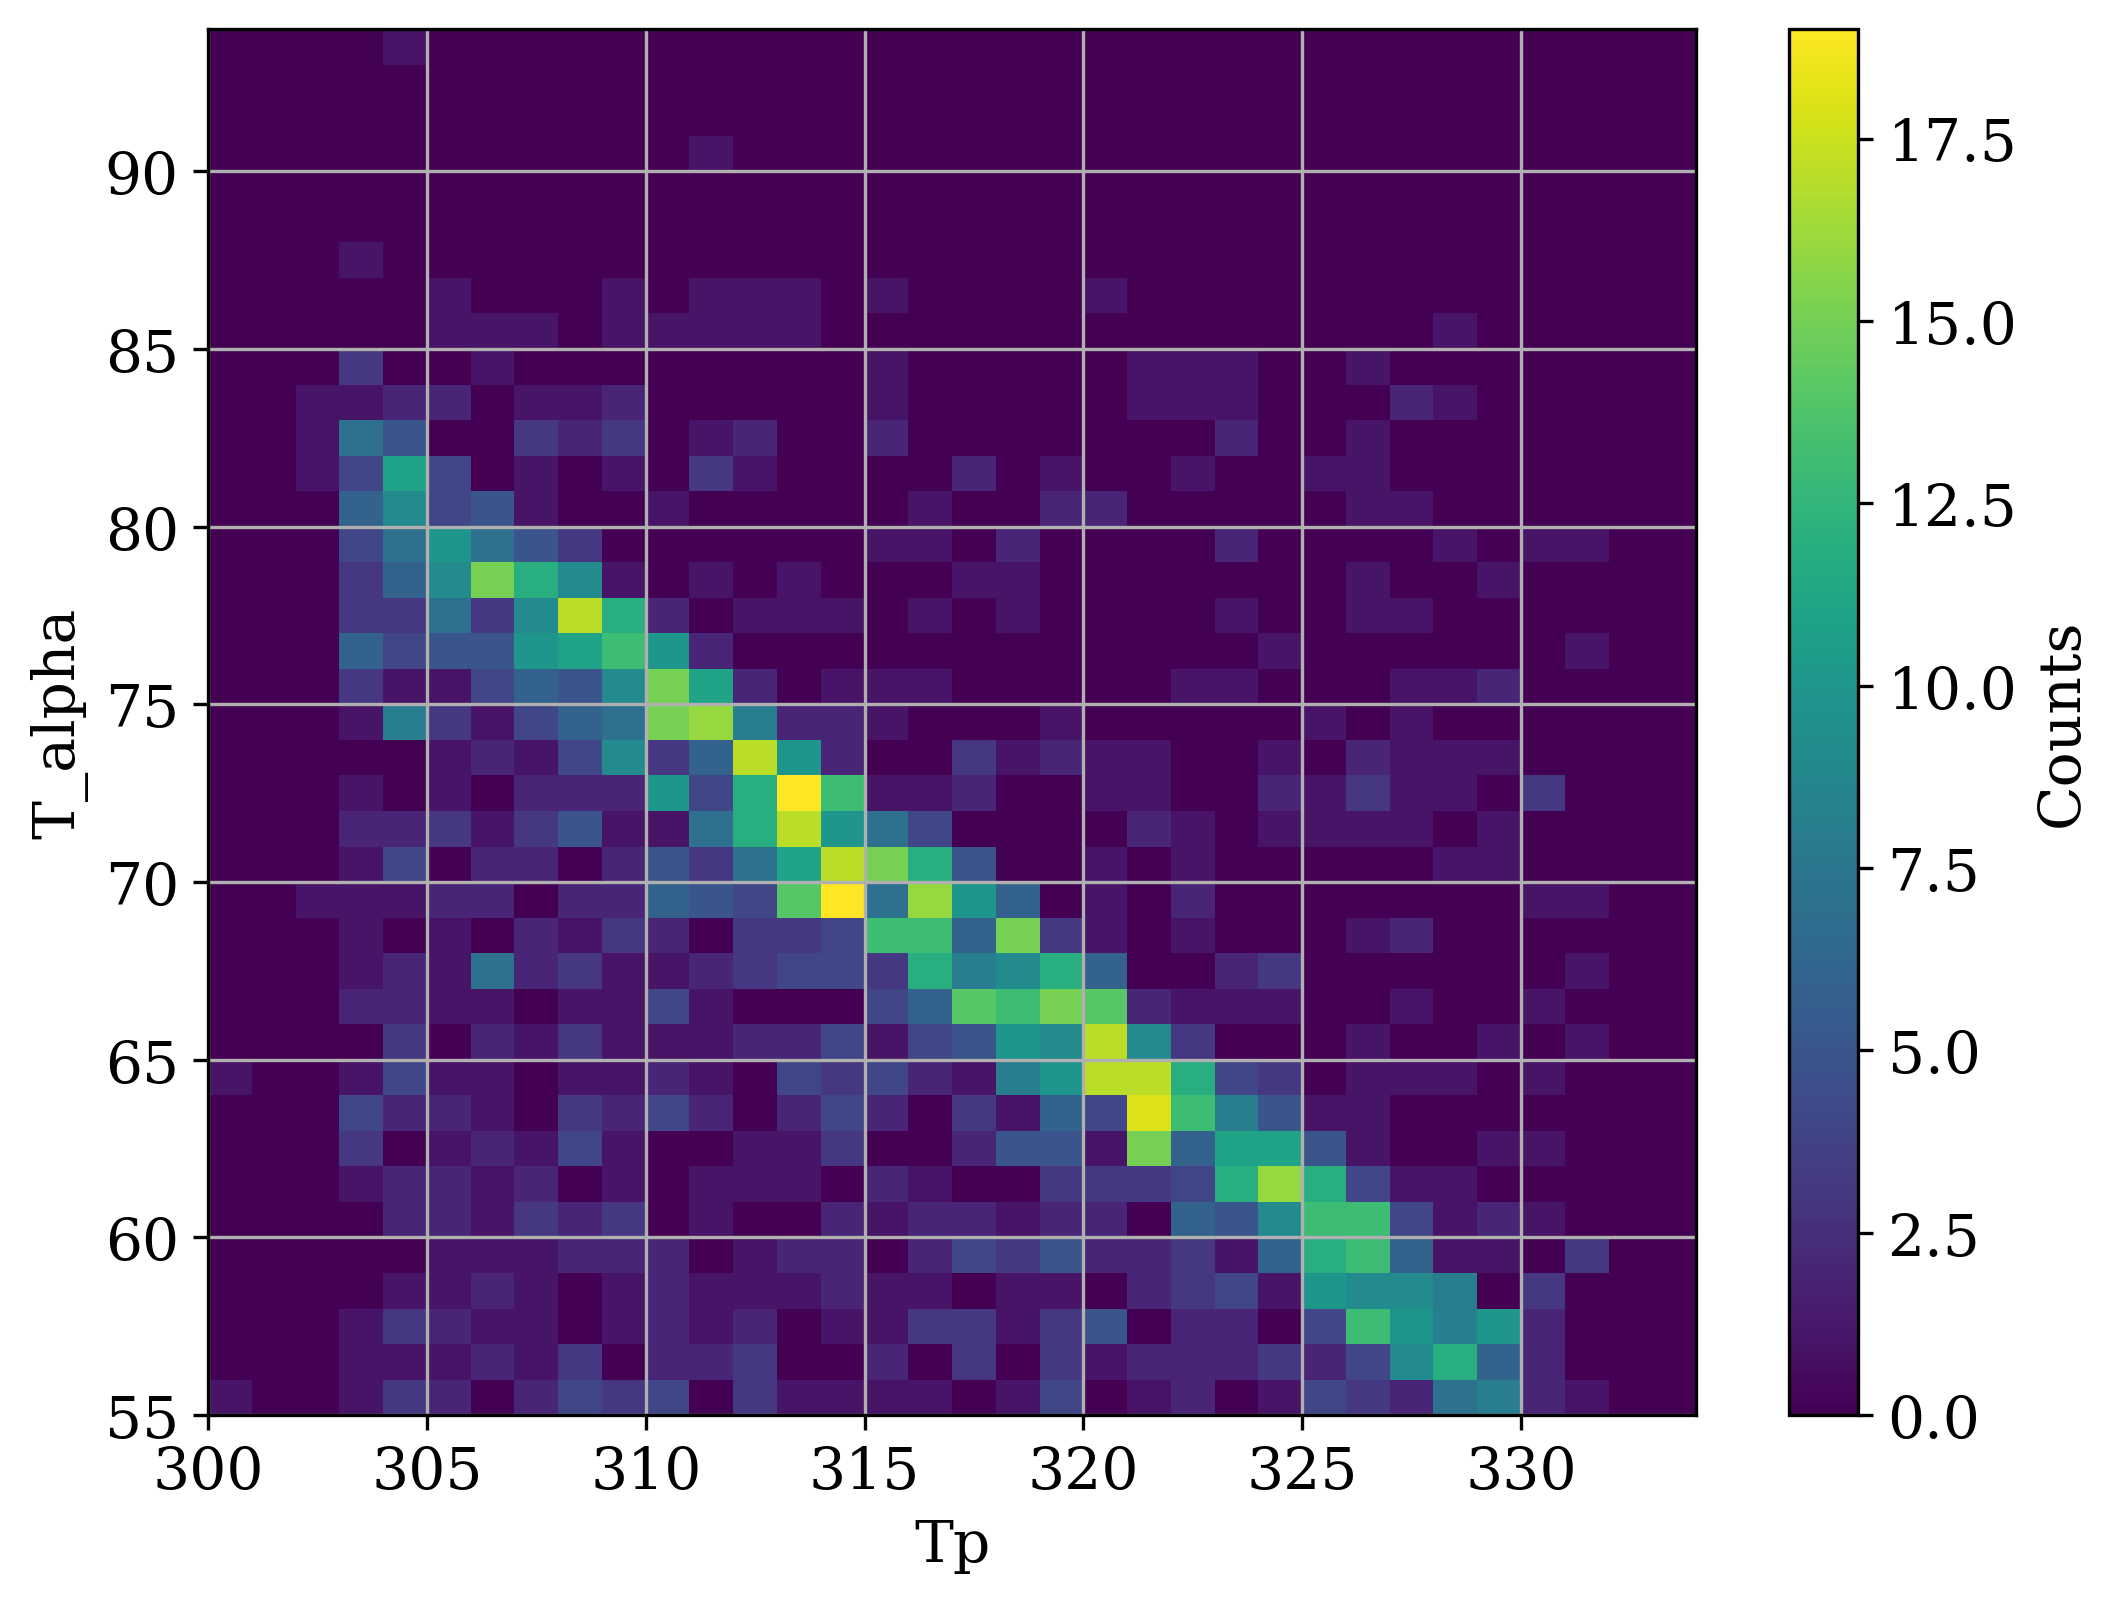

In [68]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=Tp
y_axis_variable=T_alpha
# #hist range
x_axis_range_min = 300
x_axis_range_max = 335
y_axis_range_min = 55
y_axis_range_max = 95
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 1)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('Tp')
ax.set_ylabel('T_alpha')
ax.grid()

In [69]:
# Tp = []
# for n in GRX_gated:
#     Tp.append((((n * -0.0000454324 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27)



print(Tp)

[314.7821563515354, 310.3310679475535, 305.68741421137725, 317.5721012443212, 315.24517167200656, 306.24700976306826, 326.80307288515814, 309.50582166588333, 329.47546437408755, 315.9857953341748, 327.7516946321962, 309.8919568569888, 312.49350634460643, 310.4497628309962, 324.42471237023665, 313.42333023707397, 313.42313008269684, 307.64828142778924, 312.4883573009106, 319.2647964471812, 314.98221581752705, 307.58364709798207, 325.75014948022476, 313.60361093761003, 320.06403444340754, 319.97588158852886, 311.4549525361815, 314.226822574024, 307.67635981012086, 307.0219935711623, 312.73254197127085, 328.7783544249951, 307.9621647972988, 310.3299706056846, 312.86926015485346, 328.36167791356206, 303.62316152590506, 325.3655781856421, 313.5060725682888, 310.685924097138, 314.09470360309774, 306.3075298038639, 320.841398418145, 309.4175405852161, 317.189319081858, 310.50533671854396, 304.8970345861826, 325.04397166220065, 327.27817577300266, 308.04006091227325, 317.4016031455028, 312.205

In [70]:
# リスト内包表記で各要素を足し算
S_alpha = [392 - (a + b) for a, b in zip(Tp, T_alpha)]

print(S_alpha)

[7.353083074497192, 12.580759174185005, 11.486102614127162, 5.5486444838255125, 11.766102202226875, 7.783216969658213, 6.521463427031449, 6.2440902580489706, 6.33901314168827, 7.301352420432693, 0.07549639079451254, -49.97754977397881, 6.737107035019676, 26.00720541065141, 6.287506118518138, 6.236679045354208, 6.235289543066642, 30.75283691478643, 5.087423490762831, 16.733407658367298, 2.222258897939014, 22.566991494800845, 7.374925335544958, 6.664724924065581, 1.3651818768318549, 5.765534396375642, 8.559119089141973, 7.175558186248566, 11.891287725754921, 9.790105381455874, 24.025652736670736, 5.978139222089624, 11.374632258862619, 17.70618752171424, 9.527976244188324, 5.006075505240744, 9.26256629490399, 5.669017286047165, 11.159105439613825, 4.957103623593184, 15.372503868863987, 7.858383555361399, 7.4642630949204545, 13.597371729728195, 18.09553333123972, 6.4684222338742074, 5.719148497434276, 4.443203514069751, 7.3056380509623295, 4.916716478447938, 10.319040465953037, 16.94356282

In [71]:
sum = [a + b for a, b in zip(Tp, T_alpha)]
print(sum)

[384.6469169255028, 379.419240825815, 380.51389738587284, 386.4513555161745, 380.2338977977731, 384.2167830303418, 385.47853657296855, 385.75590974195103, 385.66098685831173, 384.6986475795673, 391.9245036092055, 441.9775497739788, 385.2628929649803, 365.9927945893486, 385.71249388148186, 385.7633209546458, 385.76471045693336, 361.2471630852136, 386.91257650923717, 375.2665923416327, 389.777741102061, 369.43300850519915, 384.62507466445504, 385.3352750759344, 390.63481812316815, 386.23446560362436, 383.440880910858, 384.82444181375143, 380.1087122742451, 382.2098946185441, 367.97434726332926, 386.0218607779104, 380.6253677411374, 374.29381247828576, 382.4720237558117, 386.99392449475926, 382.737433705096, 386.33098271395284, 380.8408945603862, 387.0428963764068, 376.627496131136, 384.1416164446386, 384.53573690507955, 378.4026282702718, 373.9044666687603, 385.5315777661258, 386.2808515025657, 387.55679648593025, 384.69436194903767, 387.08328352155206, 381.68095953404696, 375.0564371794

Text(0, 0.5, 'counts')

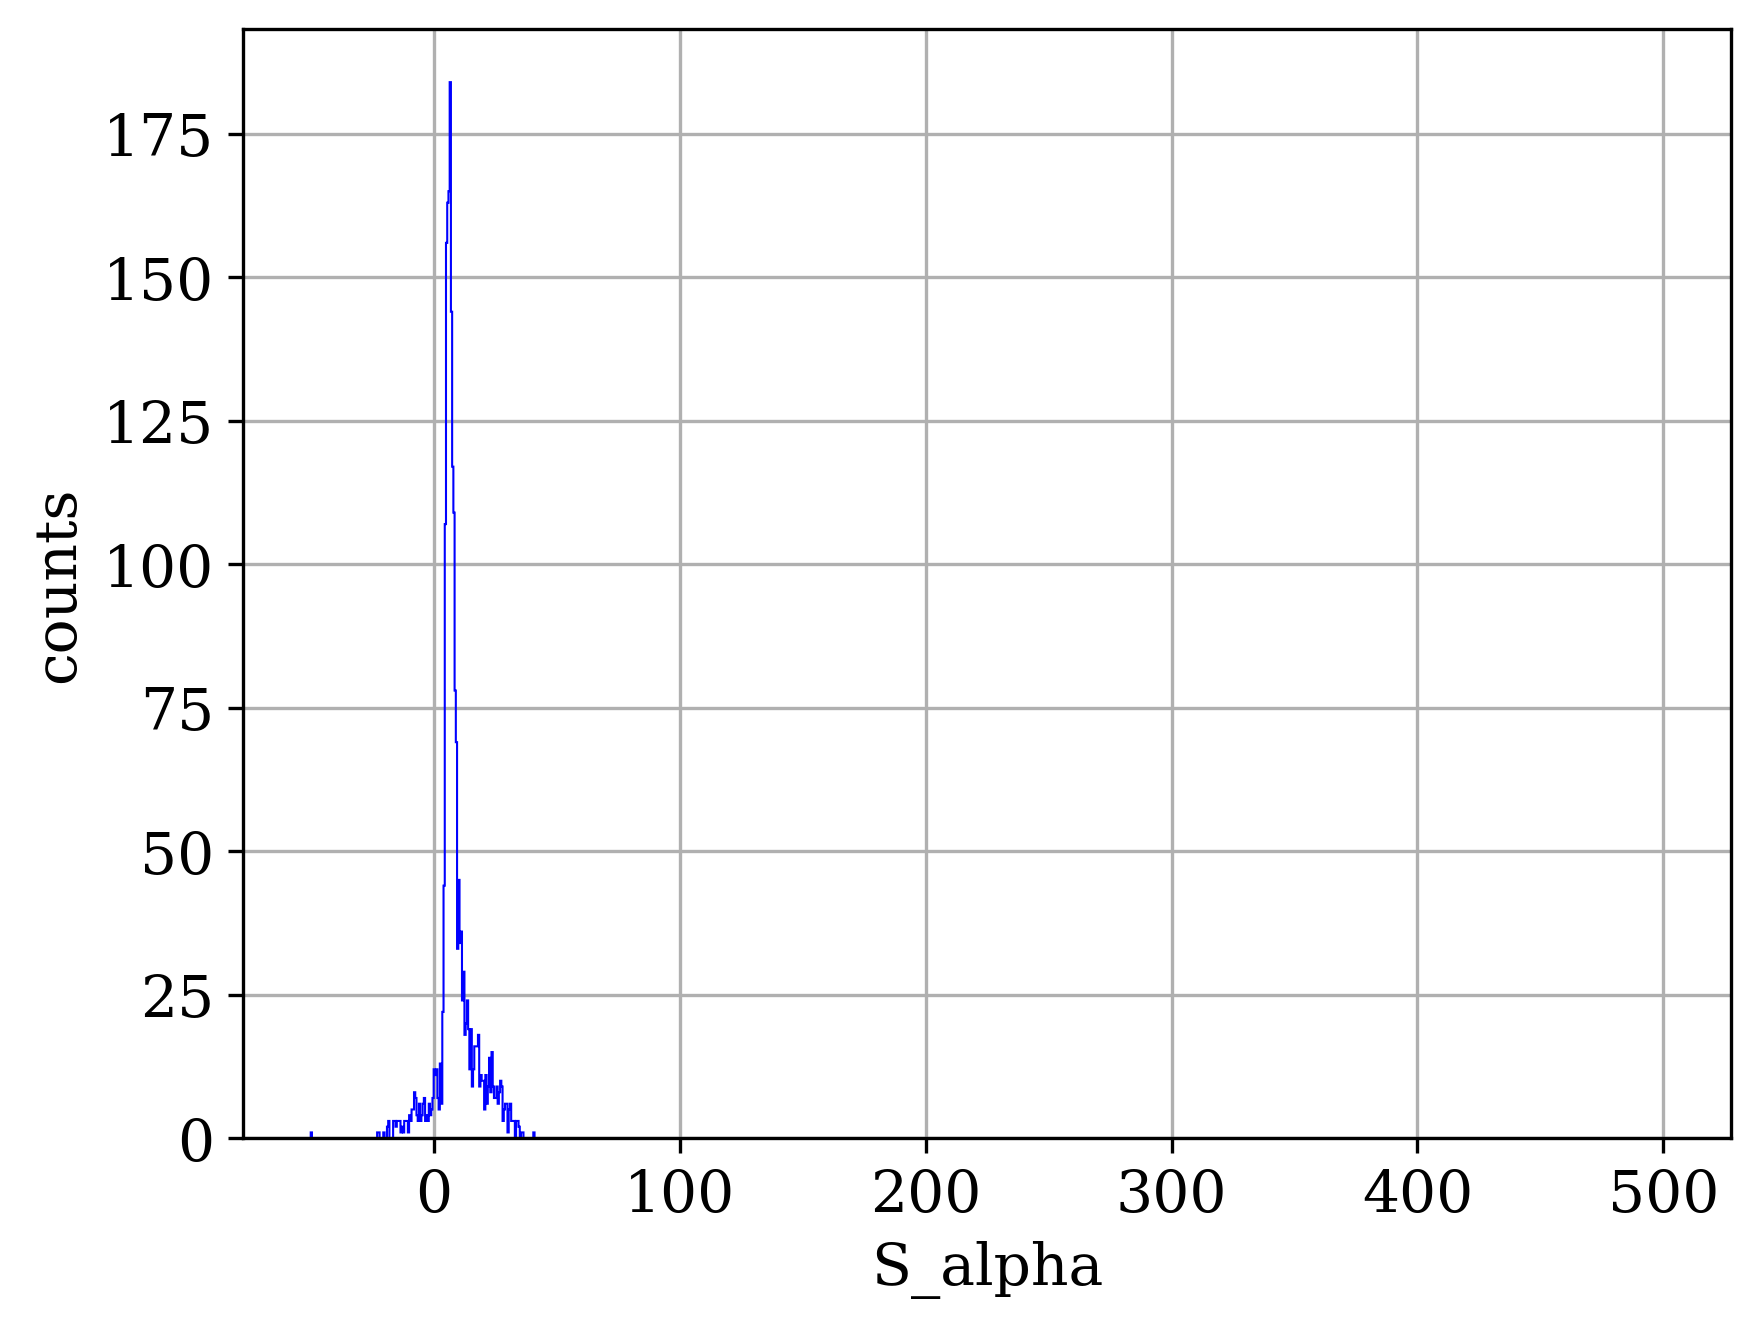

In [72]:
variables = S_alpha

#hist range
range_min=-50
range_max=500

#bin width
x_bin_width=0.5

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('S_alpha')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 622.099 ± 60.703
Mean: 6.692 ± 0.226
Sigma: 2.002 ± 0.225


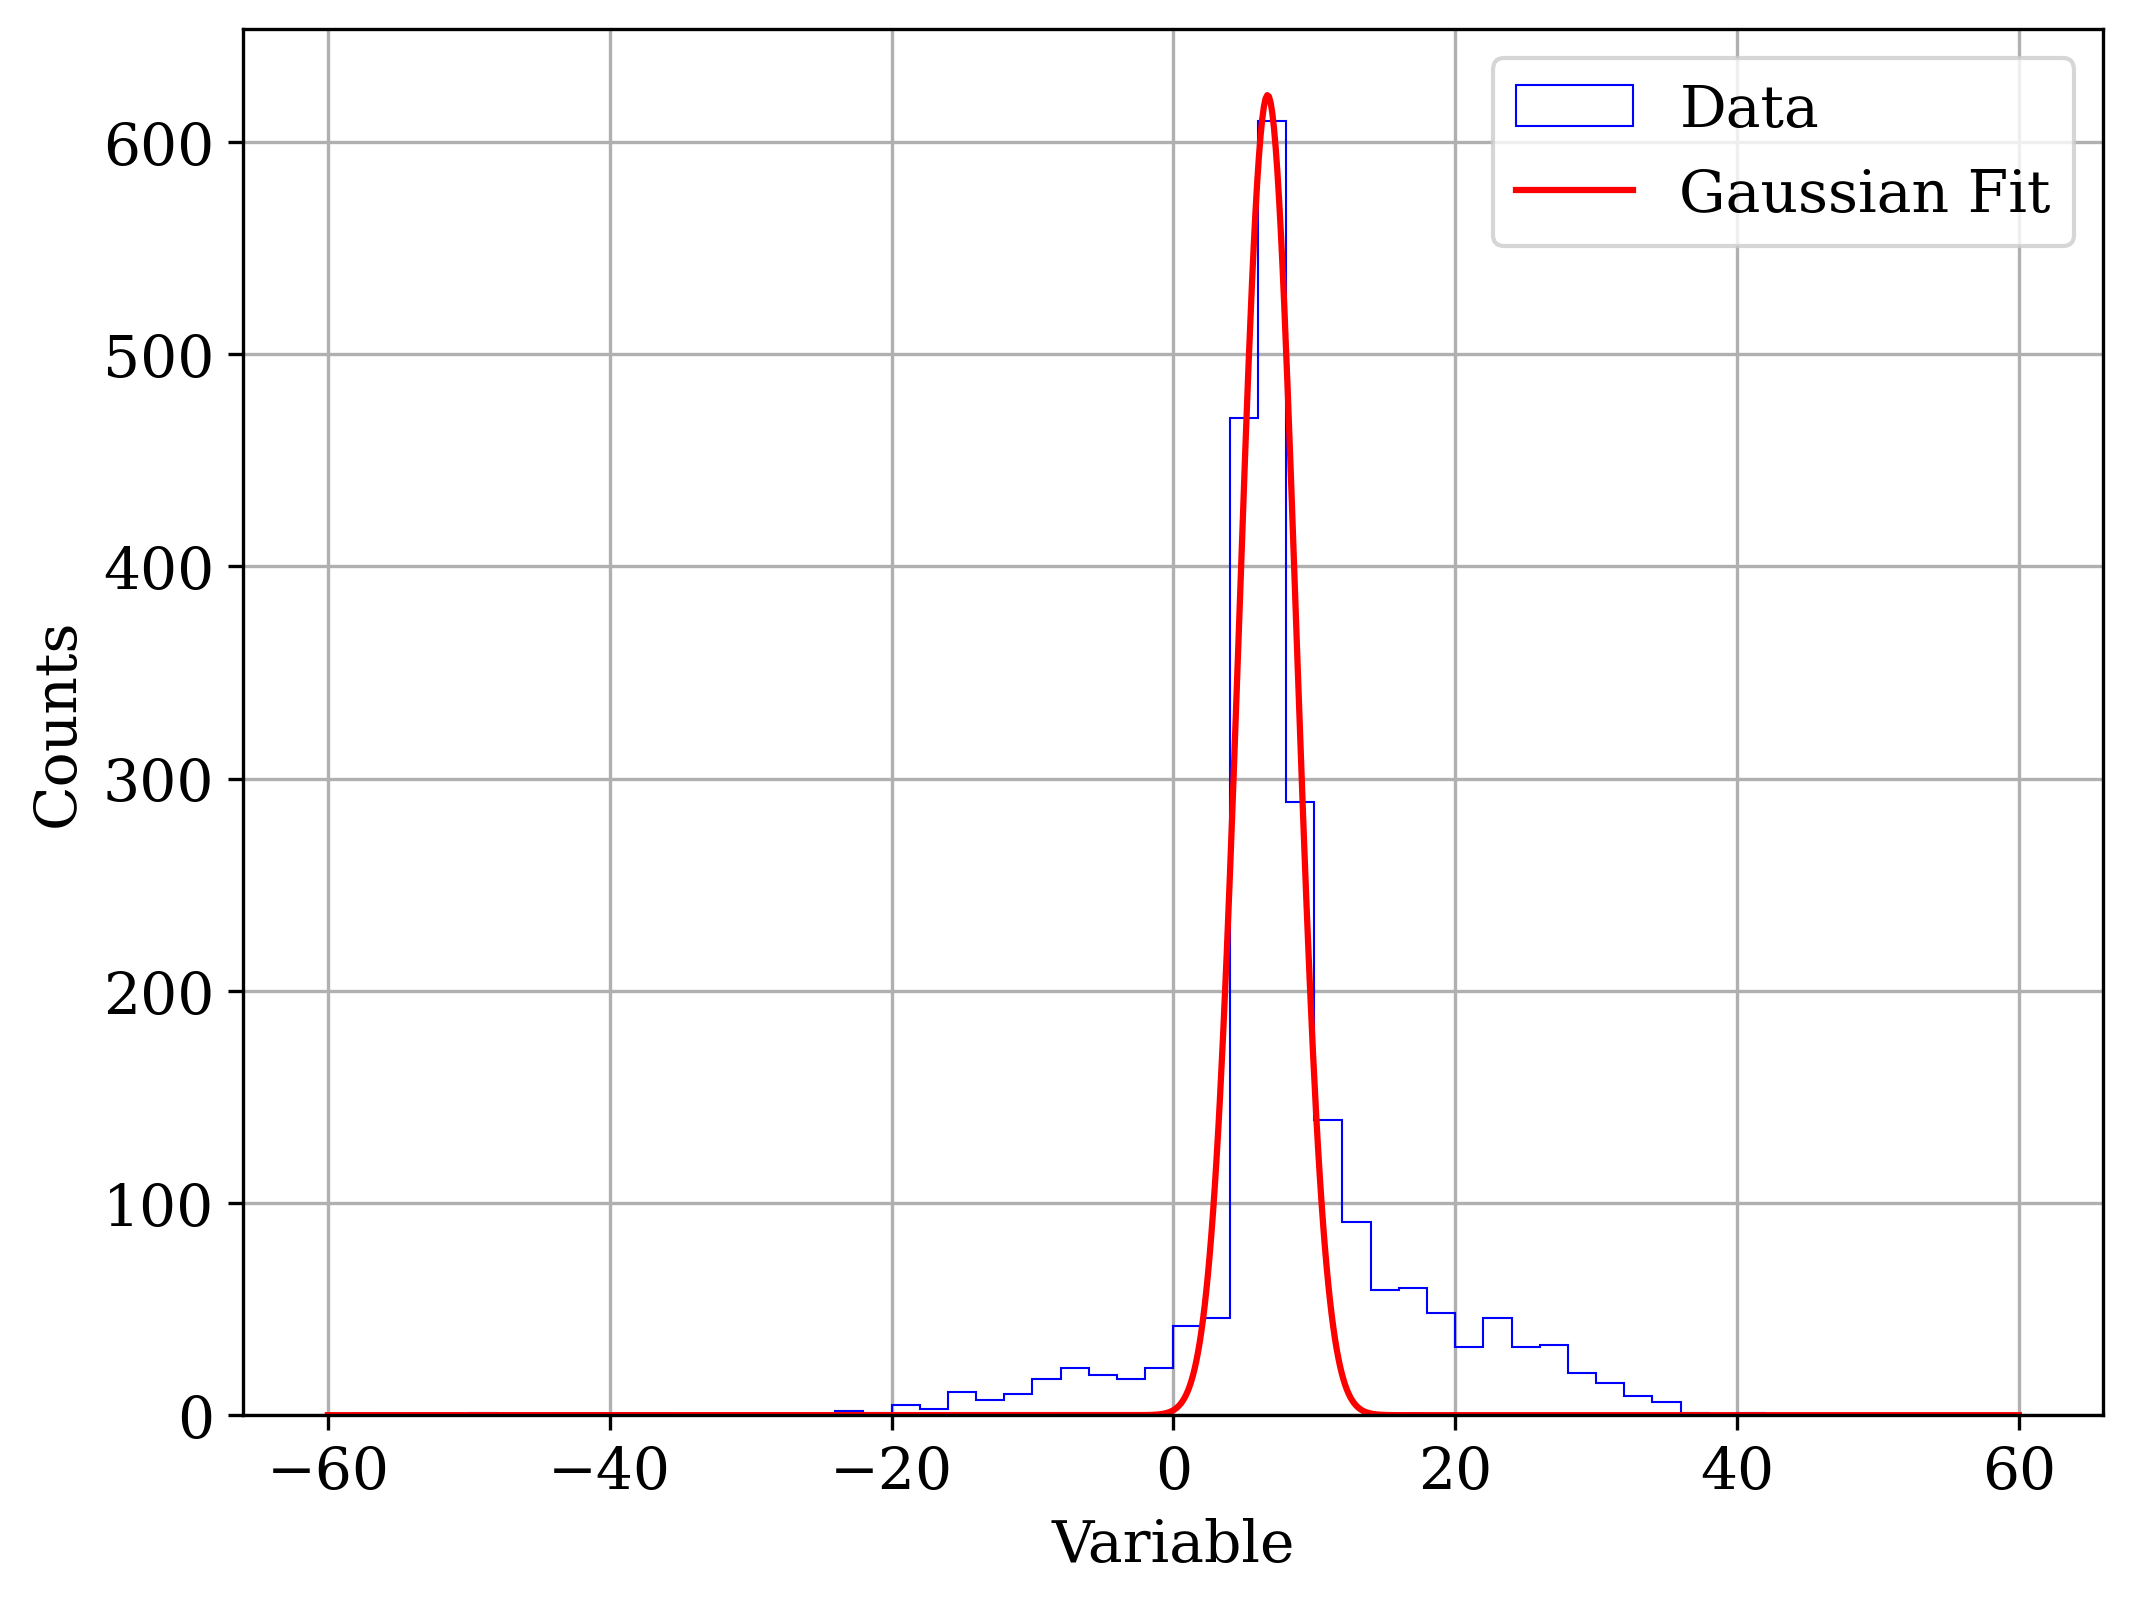

In [73]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = S_alpha
# Histogram range
hist_range_min = -60
hist_range_max = 60
# Bin width
bin_width = 2
# Fit range
fit_range_min = 0
fit_range_max = 20
# Initial parameters for the Gaussian
Amp = 175
mean = 7
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

In [74]:
Tp = []
for n in GRX_gated:
    Tp.append((((n * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27)

T_alpha = []
for n in LASX_gated:
    T_alpha.append(0.0269433333 * n + 71.8116666667 - 7.89)